# Mask Analysis —> `master_patients_masks.csv` pipeline

1. Setup & data loading
2. Mask smoothening (opening + closing + largest blob)
3. FFT/Wavelet — inside mask vs outside mask vs whole image (with diagonal emphasis instead of just vertical and horizontal edges)
4. Bone exclusion via FFT/Wavelet thresholding
5. Low vs High FM / FFM comparison — mask depth + spectral features

Audrey Xiao


## Imports & Configuration

In [ ]:

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

#image imports
from PIL import Image
import cv2
from scipy import ndimage
from scipy.fft import fft2, fftshift
import pywt                        # !pip install PyWavelets if not on comp
from skimage.morphology import (
    binary_opening, binary_closing, disk,
    label as sk_label, remove_small_objects
)
from skimage.measure import regionprops

#statistics
from scipy.stats import mannwhitneyu, pearsonr

#plotting
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

print('All imports OK')

All imports OK


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# path configration
DRIVE_ROOT = Path('/content/drive/MyDrive')

# dataset notes: master_patients_masks.csv is the long-format manifest produced from the xlsx
# Each row = one (patient, region, image_index) triple with direct paths.
CSV_PATH = DRIVE_ROOT / 'Body Composition 2026/prediction_pipeline/master_patients_masks.csv'


# loading the manifests
def rebase(p: str) -> Path:
    """Remap '/content/gdrive/MyDrive/…' → '/content/drive/MyDrive/…'."""
    return Path(str(p).replace('/content/gdrive/MyDrive/', str(DRIVE_ROOT) + '/'))

df_raw = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df_raw):,} rows | columns: {df_raw.columns.tolist()}")

#local mounting
for col in ('source_path', 'universeg_mask_path', 'echocare_mask_path'):
    df_raw[col] = df_raw[col].astype(str).apply(rebase)

# common renames of columns for analysis
df = df_raw.rename(columns={
    'source_path':         'img_path',
    'universeg_mask_path': 'universeg_path',
    'echocare_mask_path':  'echocare_path',
}).copy()

# formatting
df['region'] = df['region'].str.lower()

print(f"DataFrame: {len(df):,} rows | {df.patient_id.nunique()} patients | "
      f"regions: {sorted(df.region.unique())} | sites: {sorted(df.site.unique())}")
df.head(3)


Loaded 1,279 rows | columns: ['patient_id', 'region', 'img_idx', 'source_path', 'universeg_mask_path', 'echocare_mask_path', 'site', 'fat_mass', 'fat_free_mass', 'n_abd', 'n_bicep', 'n_quad', 'has_all_regions']
DataFrame: 1,279 rows | 110 patients | regions: ['abd', 'bicep', 'quad'] | sites: ['bwh', 'ethiopia', 'minnesota']


,patient_id,region,img_idx,img_path,universeg_path,echocare_path,site,fat_mass,fat_free_mass,n_abd,n_bicep,n_quad,has_all_regions
0,4,abd,0,/content/drive/MyDrive/Body Composition 2026/c...,/content/drive/MyDrive/Body Composition 2026/S...,/content/drive/MyDrive/Body Composition 2026/S...,ethiopia,0.0055,1.9672,7,6,6,1
1,4,abd,1,/content/drive/MyDrive/Body Composition 2026/c...,/content/drive/MyDrive/Body Composition 2026/S...,/content/drive/MyDrive/Body Composition 2026/S...,ethiopia,0.0055,1.9672,7,6,6,1
2,4,abd,2,/content/drive/MyDrive/Body Composition 2026/c...,/content/drive/MyDrive/Body Composition 2026/S...,/content/drive/MyDrive/Body Composition 2026/S...,ethiopia,0.0055,1.9672,7,6,6,1


In [ ]:
# finding the high and low FM and FFM
# Use per-patient median FM (all images of the same patient share the same FM)
patient_fm = df.drop_duplicates('patient_id').set_index('patient_id')['fat_mass']

LOW_THRESH  = patient_fm.quantile(0.33)   # lower 33 %
HIGH_THRESH = patient_fm.quantile(0.66)   # upper 33 %

df['fm_group'] = pd.cut(
    df['fat_mass'],
    bins=[-np.inf, LOW_THRESH, HIGH_THRESH, np.inf],
    labels=['low', 'mid', 'high']
)

ffm_low  = df['fat_free_mass'].quantile(0.33)
ffm_high = df['fat_free_mass'].quantile(0.66)
df['ffm_group'] = pd.cut(
    df['fat_free_mass'],
    bins=[-np.inf, ffm_low, ffm_high, np.inf],
    labels=['low', 'mid', 'high']
)

print(f'FM  thresholds — low < {LOW_THRESH:.4f}, high > {HIGH_THRESH:.4f}')
print(f'FFM thresholds — low < {ffm_low:.4f},  high > {ffm_high:.4f}')
print(df['fm_group'].value_counts().sort_index())

FM  thresholds — low < 0.1651, high > 0.2893
FFM thresholds — low < 1.8783,  high > 2.2117
fm_group
low     439
mid     407
high    433
Name: count, dtype: int64



## 1. Helper Functions

for wavelet analysis and for masking and smoothing (largest section)

In [ ]:

# load helpers

def load_image(path, as_gray=True):
    """Load an image from *path* as a float32 array in [0, 1]."""
    img = np.array(Image.open(path).convert('L' if as_gray else 'RGB'), dtype=np.float32)
    return img / 255.0


def load_mask(path, threshold=0.5):
    """Load a PNG mask and binarise at *threshold*."""
    raw = np.array(Image.open(path).convert('L'), dtype=np.float32) / 255.0
    return (raw >= threshold).astype(np.uint8)


# mask smoothening helpers

def smooth_mask(binary_mask, open_r=3, close_r=5, keep_largest=True):
    """
    Smooth a binary mask using:
      1. Morphological opening  (removes small spurs / noise)
      2. Morphological closing  (fills small holes)
      3. Optionally keep only the largest connected blob
    """
    m = binary_mask.astype(bool)

    # Opening removes small objects outside real region!
    m = binary_opening(m, footprint=disk(open_r))

    # Closing  fills holes inside real region!!
    m = binary_closing(m, footprint=disk(close_r))

    if keep_largest:
        labeled, n_blobs = ndimage.label(m)
        if n_blobs > 1:
            sizes = ndimage.sum(m, labeled, range(1, n_blobs + 1))
            largest = np.argmax(sizes) + 1
            m = (labeled == largest)

    return m.astype(np.uint8)


def mask_depth(binary_mask):
    """
    Compute the mean depth (mm proxy) of the muscle region.
    Returns the mean row-index of mask pixels (higher = deeper).
    """
    rows, _ = np.where(binary_mask > 0)
    if len(rows) == 0:
        return np.nan
    return float(rows.mean())


print('Utility functions defined.')

Utility functions defined.


In [ ]:
# FFT helpers

def compute_fft_spectrum(img):
    F  = fftshift(fft2(img))
    return np.log1p(np.abs(F))


def diagonal_energy_ratio(spectrum):
    """
    Compare diagonal vs horizontal/vertical energy in a 2-D FFT spectrum
    """
    H, W   = spectrum.shape
    cy, cx = H // 2, W // 2
    ys     = np.arange(H) - cy
    xs     = np.arange(W) - cx
    XX, YY = np.meshgrid(xs, ys)
    angle  = np.arctan2(YY, XX)          # −π … +π

    # Diagonal band: |angle mod 90°| in [22.5°, 67.5°]
    angle_mod = np.abs(angle % (np.pi / 2))
    diag_mask = (angle_mod >= np.pi / 8) & (angle_mod <= 3 * np.pi / 8)
    axial_mask = ~diag_mask

    diag_e  = spectrum[diag_mask].sum()
    axial_e = spectrum[axial_mask].sum()
    return diag_e / (axial_e + 1e-9)


def extract_fft_features(img, mask):
    """
    Extract FFT features for: whole image, inside mask, outside mask
    """
    mask_b = mask.astype(bool)

    def _roi_features(roi_img):
        spec       = compute_fft_spectrum(roi_img)
        energy     = spec.sum()
        diag_ratio = diagonal_energy_ratio(spec)
        return energy, diag_ratio

    # whole image
    w_e, w_d   = _roi_features(img)

    # inside mask (zero out outside)
    img_in     = img * mask_b
    i_e, i_d   = _roi_features(img_in)

    # outside mask
    img_out    = img * (~mask_b)
    o_e, o_d   = _roi_features(img_out)

    return dict(
        whole_energy=w_e,   whole_diag_ratio=w_d,
        inside_energy=i_e,  inside_diag_ratio=i_d,
        outside_energy=o_e, outside_diag_ratio=o_d,
    )


print('FFT helpers defined.')

FFT helpers defined.


In [ ]:
# wavelet helpers

WAVELET   = 'db4'
WV_LEVEL  = 3


def extract_wavelet_features(img, mask, wavelet=WAVELET, level=WV_LEVEL):
    """
    2-D DWT feature extraction for whole image / inside mask / outside mask
    """
    mask_b = mask.astype(bool)

    def _wv_feats(roi_img):
        coeffs = pywt.wavedec2(roi_img, wavelet=wavelet, level=level)
        feats  = {}
        total_diag   = 0.0
        total_detail = 0.0
        for lvl, detail in enumerate(coeffs[1:], start=1):
            cH, cV, cD = detail
            eH, eV, eD = (cH**2).sum(), (cV**2).sum(), (cD**2).sum()
            feats[f'L{lvl}_H_energy'] = eH
            feats[f'L{lvl}_V_energy'] = eV
            feats[f'L{lvl}_D_energy'] = eD
            total_diag   += eD
            total_detail += eH + eV + eD
        feats['diag_fraction'] = total_diag / (total_detail + 1e-9)
        return feats

    rois = {
        'whole':   img,
        'inside':  img * mask_b,
        'outside': img * (~mask_b),
    }

    out = {}
    for roi_name, roi_img in rois.items():
        feats = _wv_feats(roi_img)
        for k, v in feats.items():
            out[f'{roi_name}_{k}'] = v
    return out


print('Wavelet helpers defined.')

Wavelet helpers defined.


In [ ]:
# bone exlcusion and wavelet thresholding

def bone_mask_from_fft(img, low_cutoff=0.05, high_cutoff=0.45,
                       intensity_thresh=0.75, dilate_r=3):
    """
    Estimate a bone-shadow mask- need clinical validataion

    1. High-frequency band energy map: bone surfaces create
       strong specular reflections with broad high-freq energy.
    2. Intensity thresholding: bone appears very bright (high
       echogenicity) OR produces a completely dark acoustic shadow
       below it.
    """
    H, W  = img.shape
    cy, cx = H // 2, W // 2

    # --- 1. Band-pass filter in Fourier domain ---
    F     = fftshift(fft2(img))
    ys    = np.arange(H) - cy
    xs    = np.arange(W) - cx
    XX, YY = np.meshgrid(xs, ys)
    R     = np.sqrt(XX**2 + YY**2) / min(H, W)
    band  = ((R >= low_cutoff) & (R <= high_cutoff)).astype(float)
    F_bp  = fftshift(F * band)    # back to standard layout
    hf_img = np.abs(np.fft.ifft2(F_bp)).astype(np.float32)
    hf_img = (hf_img - hf_img.min()) / (hf_img.max() - hf_img.min() + 1e-9)

    # Threshold the band-pass image at its 90th percentile
    hf_thresh = np.percentile(hf_img, 90)
    hf_mask   = (hf_img >= hf_thresh).astype(np.uint8)

    # --- 2. Direct intensity threshold ---
    int_mask = (img >= intensity_thresh).astype(np.uint8)

    # --- Union + dilation ---
    combined = ((hf_mask | int_mask) > 0)
    dilated  = binary_closing(combined, footprint=disk(dilate_r)).astype(np.uint8)

    return dilated


def bone_mask_from_wavelet(img, level=3, wavelet=WAVELET,
                           energy_pct=90, intensity_thresh=0.75, dilate_r=3):
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)

    # Lowest-resolution detail sub-bands (largest scale features)
    cH, cV, cD = coeffs[1]    # level 1 = coarsest
    detail_energy = np.sqrt(cH**2 + cV**2 + cD**2)

    # Upsample back to original size for masking
    detail_up = cv2.resize(detail_energy, (img.shape[1], img.shape[0]),
                           interpolation=cv2.INTER_LINEAR)
    detail_up = (detail_up - detail_up.min()) / (detail_up.max() - detail_up.min() + 1e-9)

    wv_thresh = np.percentile(detail_up, energy_pct)
    wv_mask   = (detail_up >= wv_thresh).astype(np.uint8)

    int_mask  = (img >= intensity_thresh).astype(np.uint8)
    combined  = ((wv_mask | int_mask) > 0)
    dilated   = binary_closing(combined, footprint=disk(dilate_r)).astype(np.uint8)

    return dilated


def exclude_bone_from_mask(tissue_mask, bone_mask):
    return ((tissue_mask.astype(bool)) & (~bone_mask.astype(bool))).astype(np.uint8)


print('Bone-exclusion helpers defined.')

Bone-exclusion helpers defined.


---
## 2. Mask Smoothening

This section does the following:
1. it applies data augmentetation to create the largest blob by removing noise and filling holes in masks.
2. Uses data augmented to find the Largest-blob to keep only the main muscle region.
3. Quantified % area change per region.

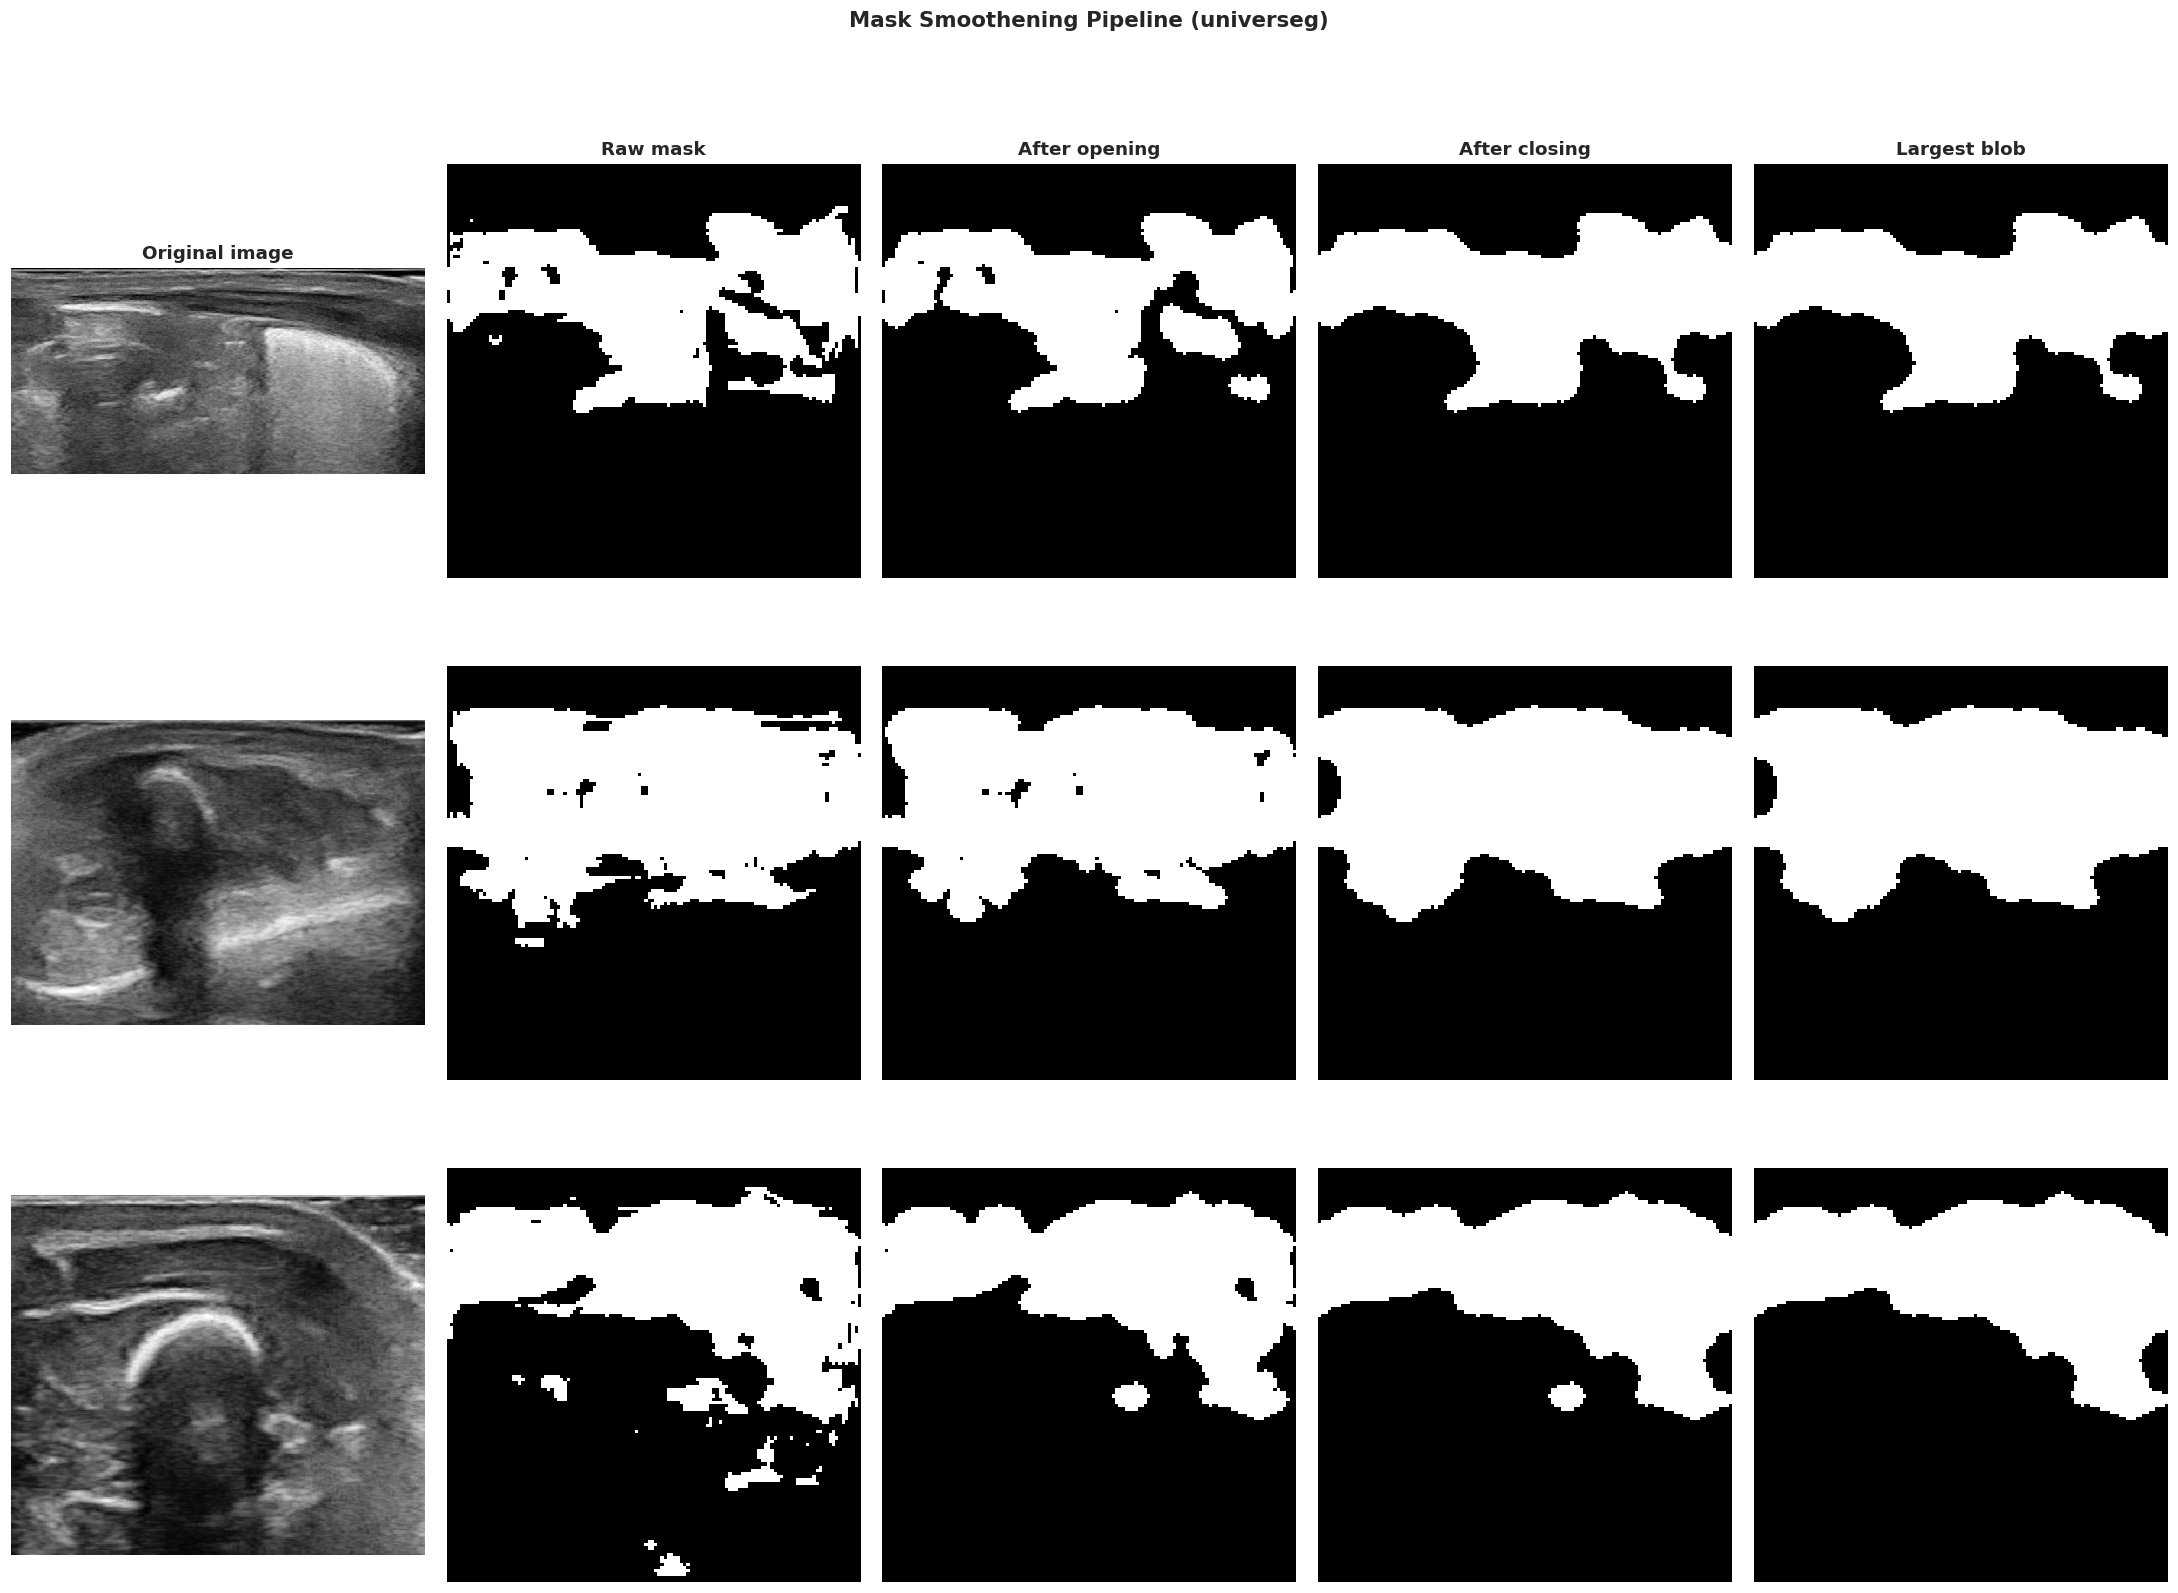

In [ ]:
# pick one representative sample per region for the demo
# (Uses the first row with a valid path for each region)
MASK_TYPE = 'universeg'   # 'universeg' | 'echocare'

mask_col = 'universeg_path' if MASK_TYPE == 'universeg' else 'echocare_path'

demo_rows = (
    df.groupby('region', observed=True)
      .first()
      .reset_index()
)

fig, axes = plt.subplots(
    nrows=len(demo_rows), ncols=5,
    figsize=(20, 5 * len(demo_rows))
)

col_titles = ['Original image', 'Raw mask', 'After opening', 'After closing', 'Largest blob']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold')

open_r_param  = 3   # THESE CAN BE changed! This could be optimized, used random
close_r_param = 5

for row_idx, row in demo_rows.iterrows():
    # for debugging- make sure it is a valid file
    img_path = Path(row['img_path'])
    mask_path = Path(row[mask_col])

    if not img_path.exists():
        print(f"[DEBUG] Image file does NOT exist: {img_path}")
    if not mask_path.exists():
        print(f"[DEBUG] Mask file does NOT exist: {mask_path}")
  # end of debug

    try:
        img  = load_image(img_path)
        mask = load_mask(mask_path)
    except FileNotFoundError:
        print(f"[WARN] File not found for patient {row['patient_id']} / {row['region']} — skipping.")
        for ax in axes[row_idx]:
            ax.axis('off')
        continue

    # smoothing
    after_open  = binary_opening(mask.astype(bool),  footprint=disk(open_r_param)).astype(np.uint8)
    after_close = binary_closing(after_open.astype(bool), footprint=disk(close_r_param)).astype(np.uint8)
    final_mask  = smooth_mask(mask, open_r=open_r_param, close_r=close_r_param, keep_largest=True)

    imgs_to_show = [img, mask, after_open, after_close, final_mask]
    cmaps        = ['gray', 'binary_r', 'binary_r', 'binary_r', 'binary_r']

    for col_idx, (im, cm) in enumerate(zip(imgs_to_show, cmaps)):
        ax = axes[row_idx][col_idx]
        ax.imshow(im, cmap=cm, interpolation='nearest')
        ax.axis('off')

    axes[row_idx][0].set_ylabel(
        f"Patient {row['patient_id']}\n{row['region'].upper()}",
        fontsize=10, rotation=0, labelpad=80, va='center'
    )

plt.suptitle(f'Mask Smoothening Pipeline ({MASK_TYPE})', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mask_smoothening_demo.png', bbox_inches='tight', dpi=120)
plt.show()

### 2a. Quantify smoothening effect

Mask smoothening stats:   0%|          | 0/200 [00:00<?, ?it/s]

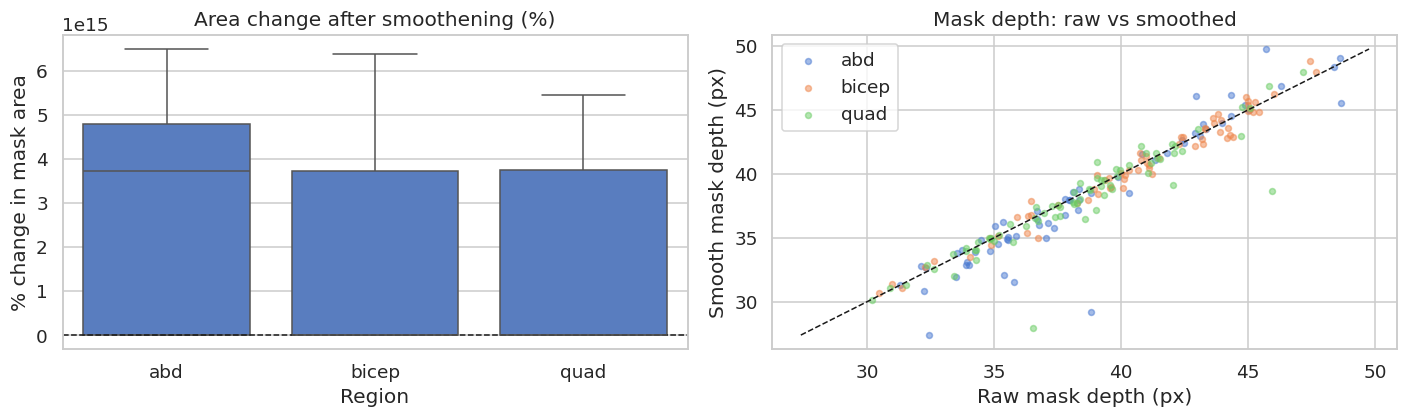

       pct_change                                                        \
            count          mean           std   min   25%           50%   
region                                                                    
abd          61.0  2.770649e+15  2.356673e+15  0.73  3.18  3.718352e+15   
bicep        67.0  1.775898e+15  2.050604e+15  0.02  2.14  7.320000e+00   
quad         72.0  1.786289e+15  2.136912e+15  0.04  1.41  5.320000e+00   

                                    
                 75%           max  
region                              
abd     4.787631e+15  6.493046e+15  
bicep   3.717997e+15  6.389589e+15  
quad    3.754581e+15  5.457617e+15  


In [ ]:
#subset of images and make quantitative obs.
SAMPLE_N = 200   # rows to sample (set None for full dataset)

rng = np.random.default_rng(42)
subset = df.sample(n=min(SAMPLE_N, len(df)), random_state=42)

records = []
for _, row in tqdm(subset.iterrows(), total=len(subset), desc='Mask smoothening stats'):
    try:
        mask = load_mask(row[mask_col])
    except FileNotFoundError:
        continue

    smooth = smooth_mask(mask)
    raw_px  = mask.sum()
    sm_px   = smooth.sum()

    records.append(dict(
        patient_id=row['patient_id'],
        region=row['region'],
        raw_area=raw_px,
        smooth_area=sm_px,
        pct_change=100 * (sm_px - raw_px) / (raw_px + 1e-6),
        raw_depth=mask_depth(mask),
        smooth_depth=mask_depth(smooth),
    ))

smooth_df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=smooth_df, x='region', y='pct_change', ax=axes[0], order=['abd','bicep','quad'])
axes[0].axhline(0, color='k', lw=1, ls='--')
axes[0].set_title('Area change after smoothening (%)')
axes[0].set_xlabel('Region'); axes[0].set_ylabel('% change in mask area')

for region, grp in smooth_df.groupby('region'):
    axes[1].scatter(grp['raw_depth'], grp['smooth_depth'], s=15, alpha=0.5, label=region)
lims = [smooth_df[['raw_depth','smooth_depth']].min().min(),
        smooth_df[['raw_depth','smooth_depth']].max().max()]
axes[1].plot(lims, lims, 'k--', lw=1)
axes[1].set_title('Mask depth: raw vs smoothed'); axes[1].legend()
axes[1].set_xlabel('Raw mask depth (px)'); axes[1].set_ylabel('Smooth mask depth (px)')

plt.tight_layout()
plt.savefig('mask_smoothening_stats.png', bbox_inches='tight')
plt.show()

print(smooth_df.groupby('region')[['pct_change']].describe().round(2))

---
## 3. FFT / Wavelet Analysis

1. Per-image spectra computed for whole image, inside-mask , and outside-mask.
2. Diagonal vs axial energy separated using FFT
3. Wavelet Analysis

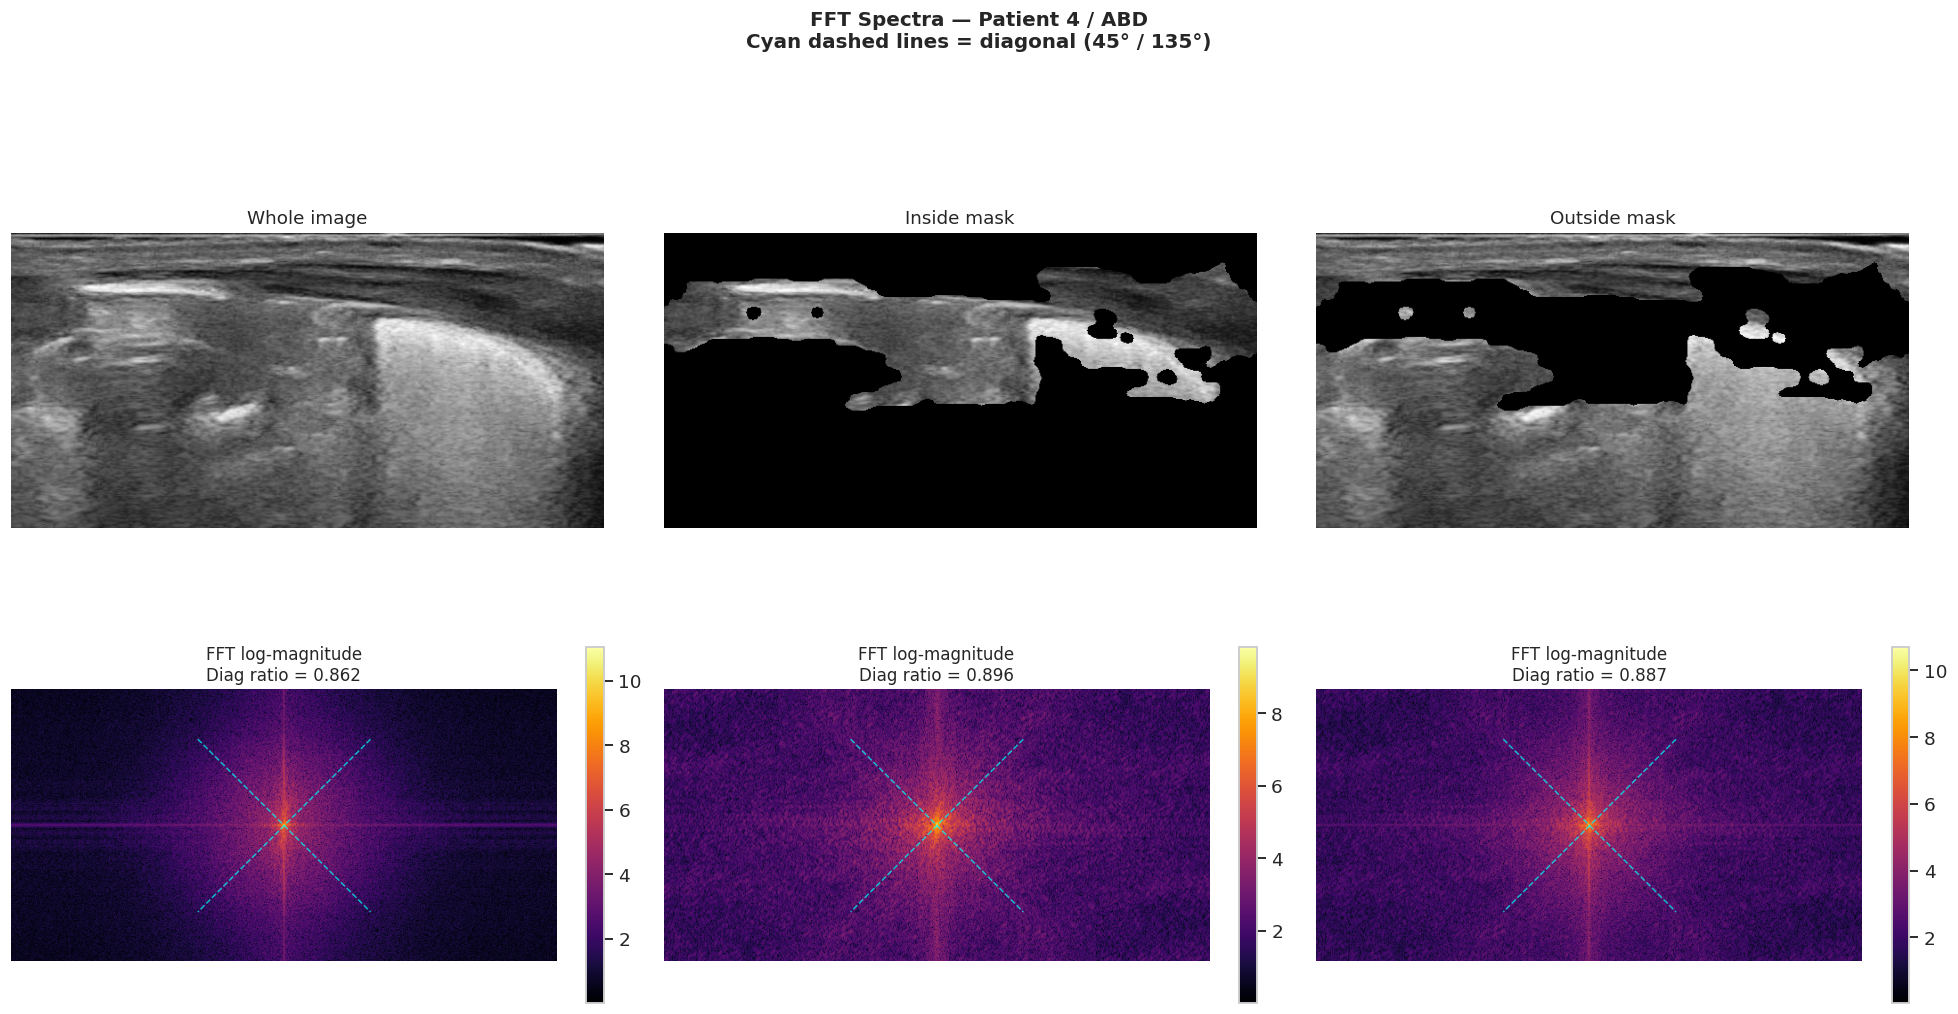

In [ ]:
demo_row = demo_rows.iloc[0]

try:
    img  = load_image(demo_row['img_path'])
    raw_mask = load_mask(demo_row[mask_col])
    # resize the raw_mask to match the image dimensions
    if img.shape != raw_mask.shape:
        # cv2.resize expects (width, height) for dsize, so img.shape[1], img.shape[0]
        raw_mask_resized = cv2.resize(raw_mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    else:
        raw_mask_resized = raw_mask
    mask = smooth_mask(raw_mask_resized)

    regions_fft = {
        'Whole image':    img,
        'Inside mask':    img * mask,
        'Outside mask':   img * (~mask.astype(bool)),
    }

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for col, (label, roi) in enumerate(regions_fft.items()):
        spec = compute_fft_spectrum(roi)
        dr   = diagonal_energy_ratio(spec)

        axes[0, col].imshow(roi, cmap='gray')
        axes[0, col].set_title(label, fontsize=12)
        axes[0, col].axis('off')

        im = axes[1, col].imshow(spec, cmap='inferno')
        plt.colorbar(im, ax=axes[1, col], fraction=0.03)
        axes[1, col].set_title(f'FFT log-magnitude\nDiag ratio = {dr:.3f}', fontsize=11)
        axes[1, col].axis('off')
        # draw diagonal overlay lines
        H, W = spec.shape
        for angle_deg in [45, 135]:
            cy_s, cx_s = H/2, W/2
            length = min(H, W) * 0.45
            rad = np.radians(angle_deg)
            dx, dy = length * np.cos(rad), length * np.sin(rad)
            axes[1, col].plot([cx_s - dx, cx_s + dx], [cy_s - dy, cy_s + dy],
                              color='cyan', lw=1, ls='--', alpha=0.7)

    plt.suptitle(
        f'FFT Spectra — Patient {demo_row["patient_id"]} / {demo_row["region"].upper()}\n'
        f'Cyan dashed lines = diagonal (45° / 135°)',
        y=1.01, fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('fft_demo.png', bbox_inches='tight')
    plt.show()

except FileNotFoundError:
    print('[WARN] Demo file not found — skipping FFT visual demo.')

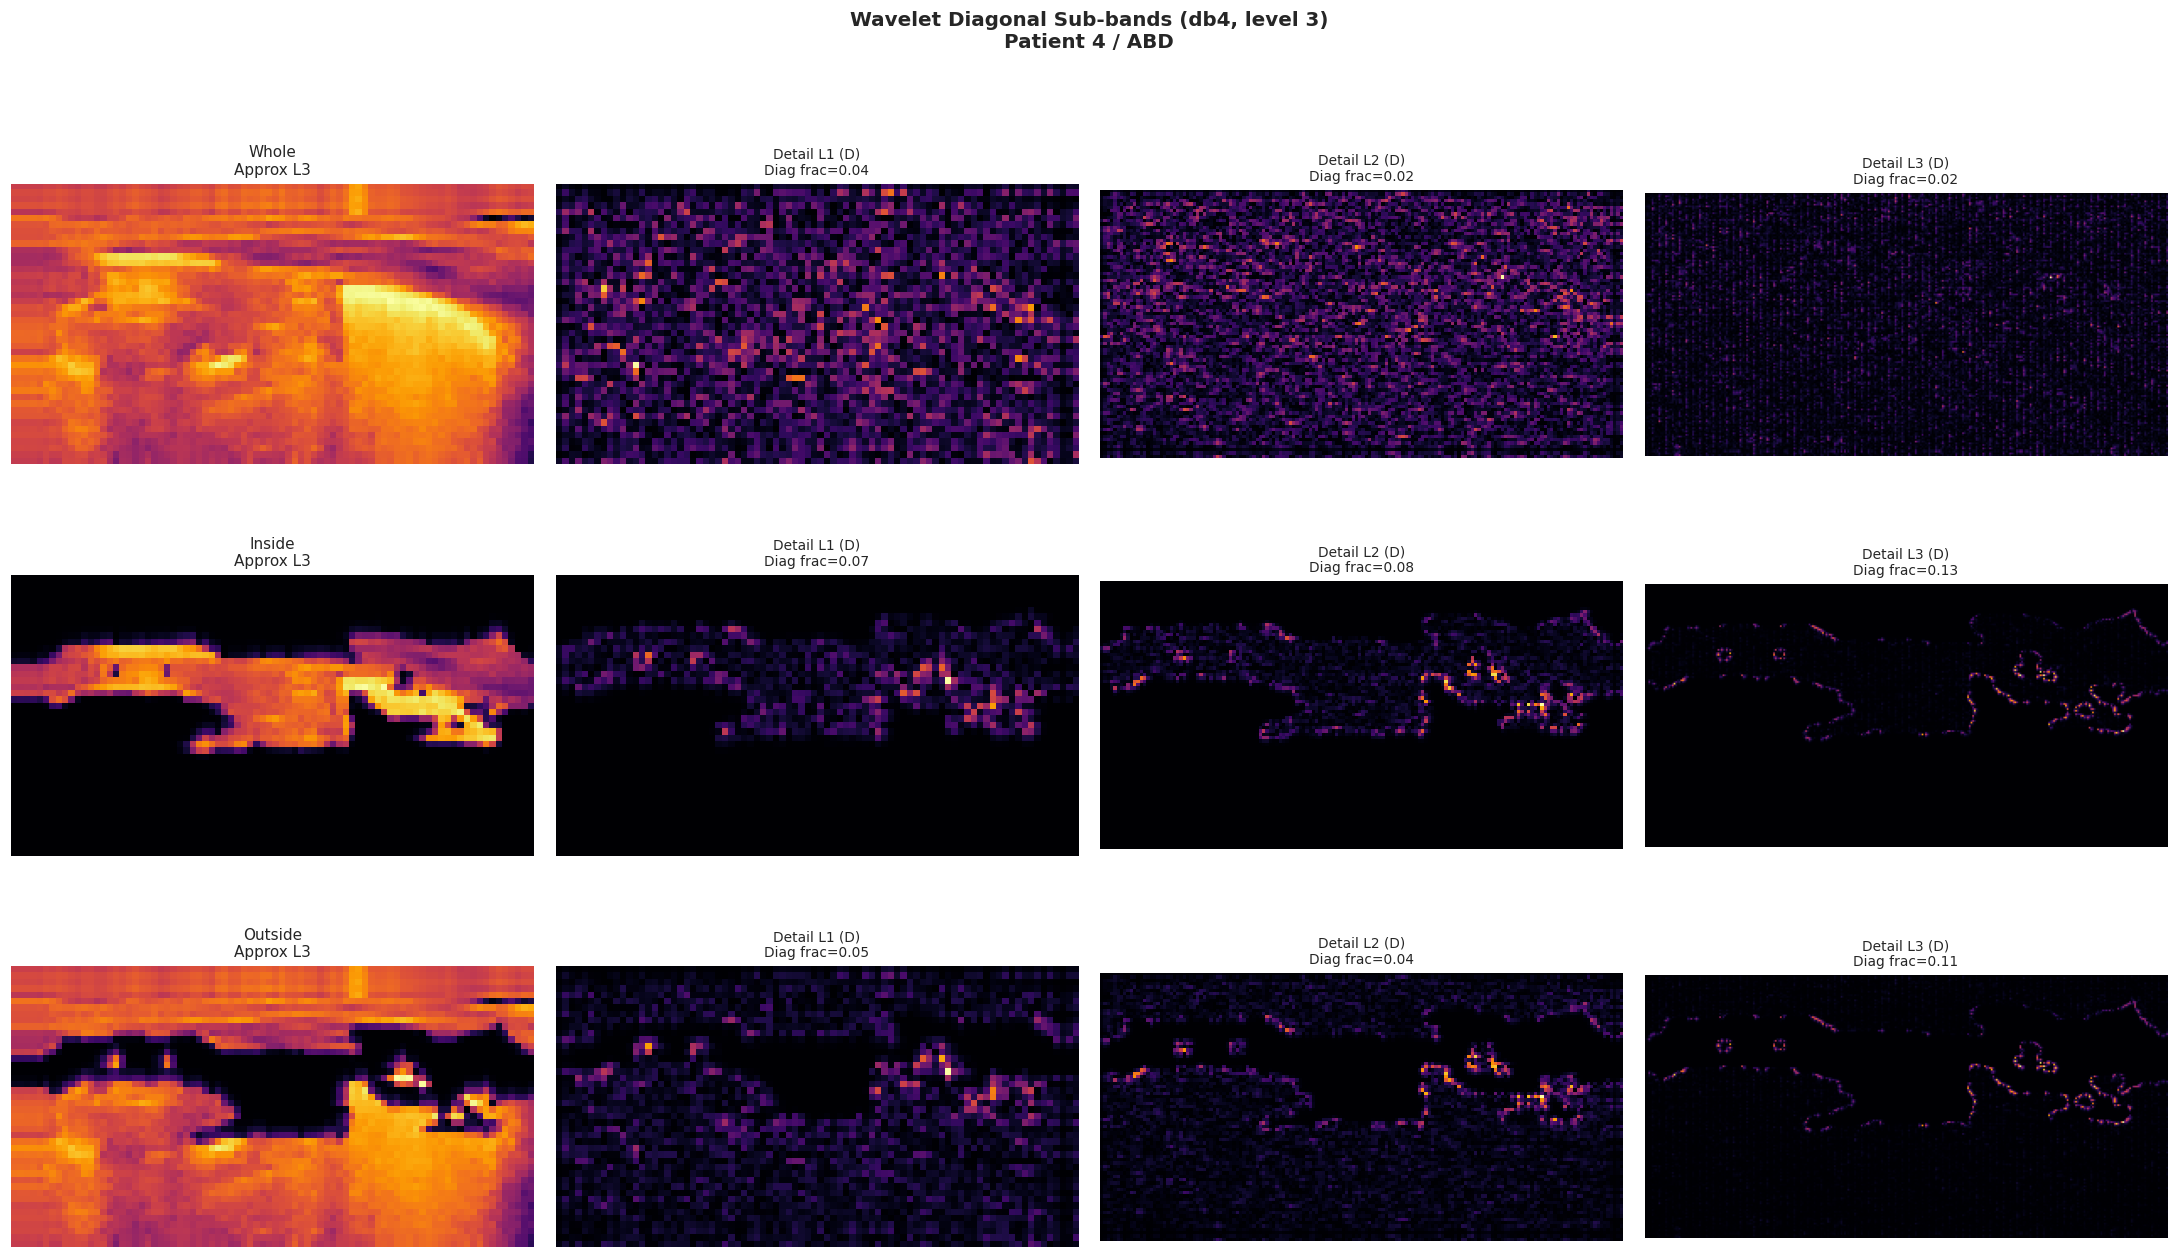

In [ ]:
# wavelet visuals of L1-L3
# background: https://www.st-andrews.ac.uk/~wjh/dataview/tutorials/dwt.html

try:
    img  = load_image(demo_row['img_path'])
    raw_mask = load_mask(demo_row[mask_col])
    # Resize the raw_mask to match the image dimensions
    if img.shape != raw_mask.shape:
        # cv2.resize expects (width, height) for dsize, so img.shape[1], img.shape[0]
        raw_mask_resized = cv2.resize(raw_mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    else:
        raw_mask_resized = raw_mask
    mask = smooth_mask(raw_mask_resized)

    rois = {
        'Whole':   img,
        'Inside':  img * mask,
        'Outside': img * (~mask.astype(bool)),
    }

    fig, axes = plt.subplots(len(rois), WV_LEVEL + 1, figsize=(5 * (WV_LEVEL + 1), 4 * len(rois)))

    for r_idx, (roi_name, roi_img) in enumerate(rois.items()):
        coeffs = pywt.wavedec2(roi_img, wavelet=WAVELET, level=WV_LEVEL)

        # Approx
        axes[r_idx, 0].imshow(np.log1p(np.abs(coeffs[0])), cmap='inferno')
        axes[r_idx, 0].set_title(f'{roi_name}\nApprox L{WV_LEVEL}', fontsize=10)
        axes[r_idx, 0].axis('off')

        # Details
        for lvl_idx, detail in enumerate(coeffs[1:], start=1):
            cH, cV, cD = detail
            diag_energy = np.log1p(np.abs(cD))
            ax = axes[r_idx, lvl_idx]
            ax.imshow(diag_energy, cmap='inferno')
            diag_frac = (cD**2).sum() / ((cH**2 + cV**2 + cD**2).sum() + 1e-9)
            ax.set_title(f'Detail L{lvl_idx} (D)\nDiag frac={diag_frac:.2f}', fontsize=9)
            ax.axis('off')

    plt.suptitle(f'Wavelet Diagonal Sub-bands ({WAVELET}, level {WV_LEVEL})\n'
                 f'Patient {demo_row["patient_id"]} / {demo_row["region"].upper()}',
                 y=1.01, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('wavelet_demo.png', bbox_inches='tight')
    plt.show()

except FileNotFoundError:
    print('[WARN] Demo file not found — skipping wavelet visual demo.')

---
## 4. Bone Exclusion via FFT / Wavelet Thresholding

 (a) FFT high-frequency band-pass + intensity threshold
 (b) Wavelet sub-band + intensity threshold
 FINALLY: we use union of a and b to form bone exlcusion

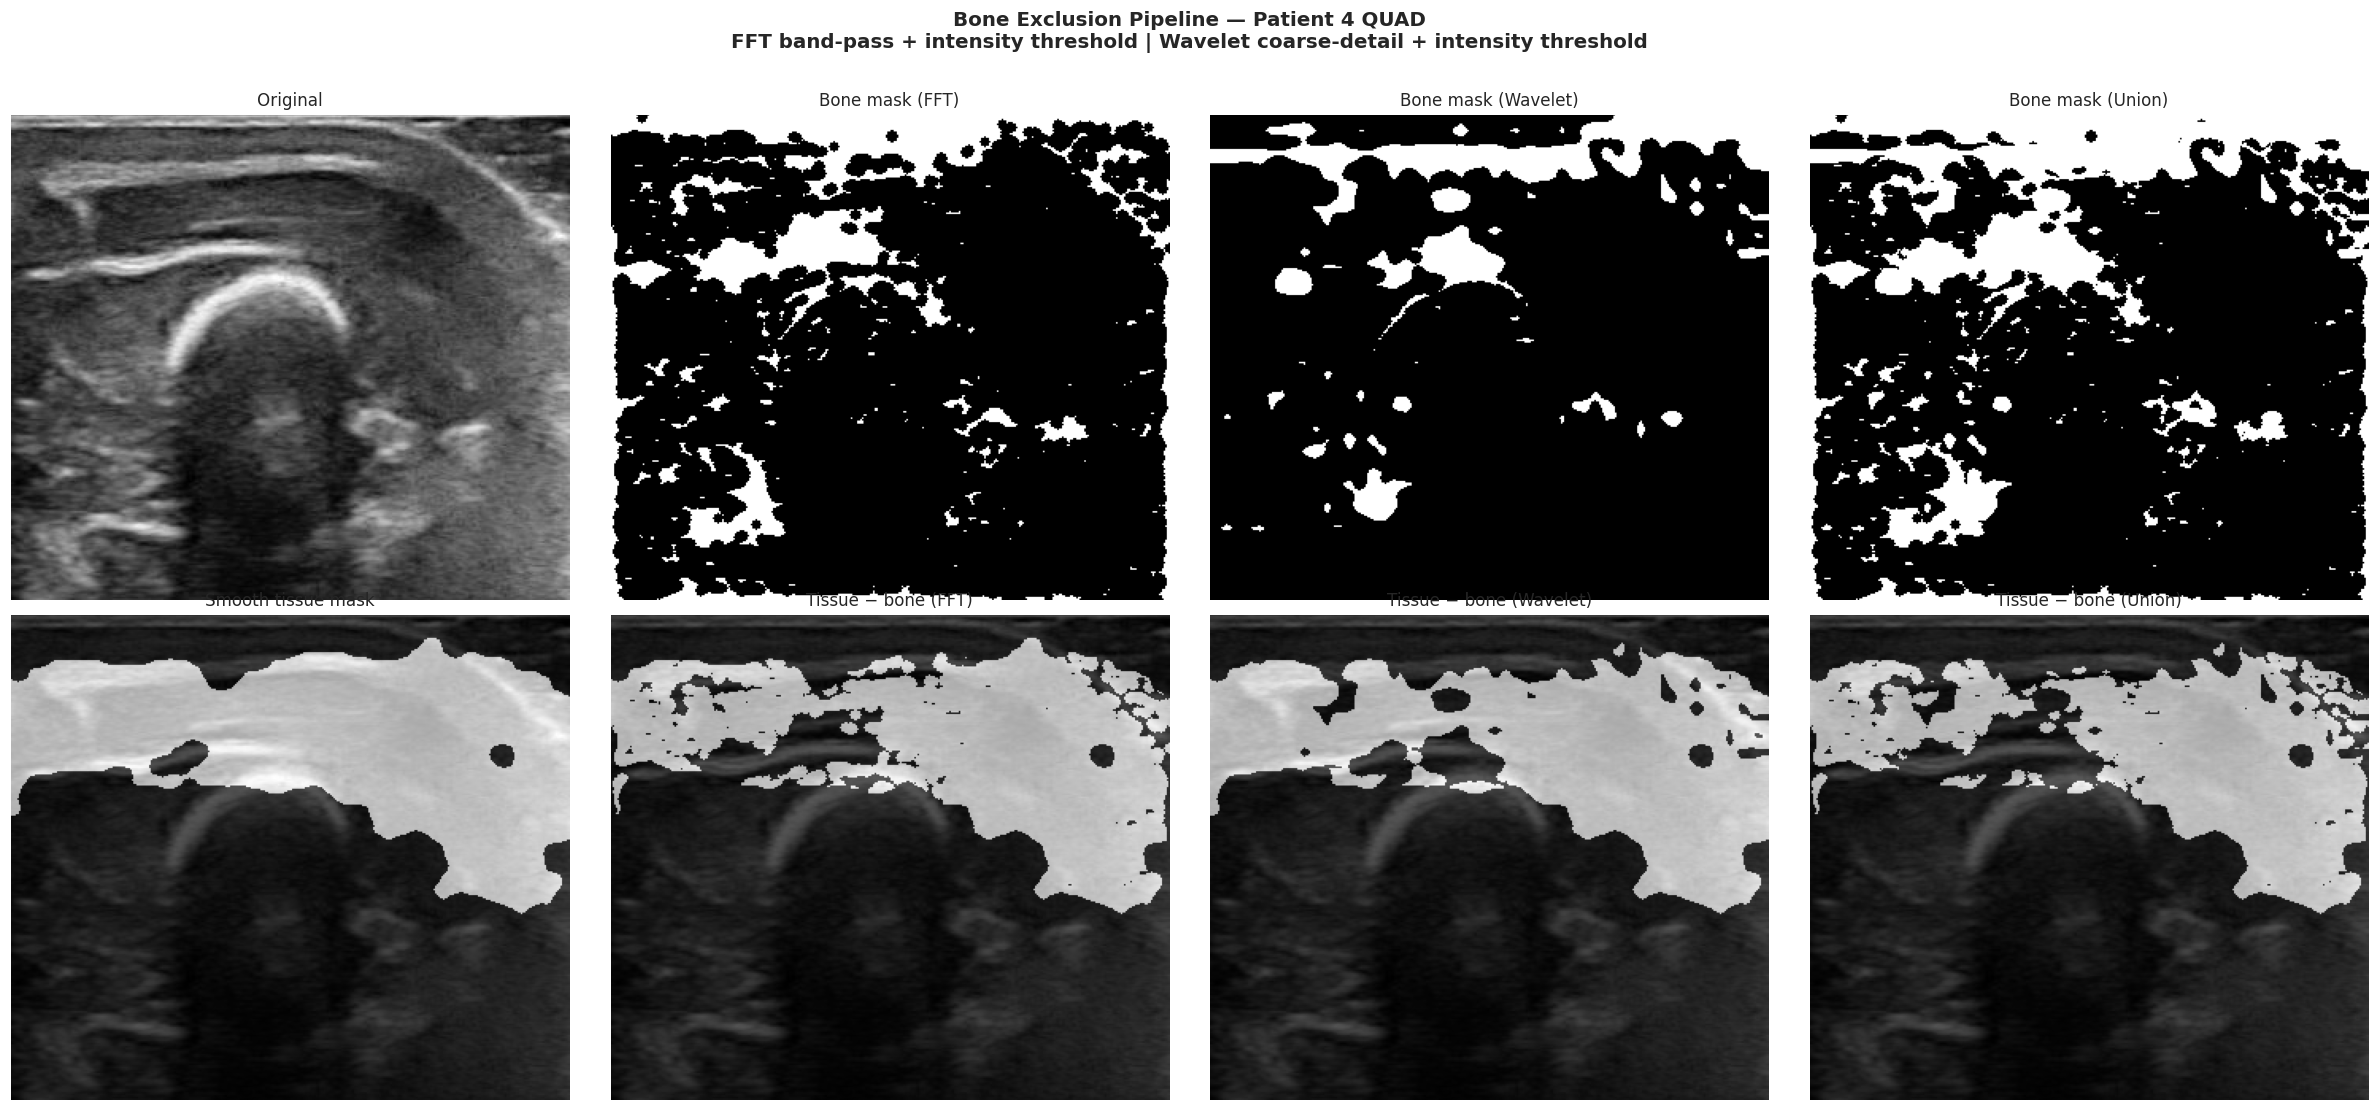

Original mask area   : 33,145 px
After bone-excl (FFT): 27,988 px (15.6% removed)
After bone-excl (WV) : 28,881 px (12.9% removed)


In [ ]:
# bone exlcusion
# Quad images are most likely to contain visible bone (femur)
quad_row = df[df['region'] == 'quad'].iloc[0]

try:
    img   = load_image(quad_row['img_path'])
    raw_mask = load_mask(quad_row[mask_col])
    # Resize the raw_mask to match the image dimensions
    if img.shape != raw_mask.shape:
        # cv2.resize expects (width, height) for dsize, so img.shape[1], img.shape[0]
        raw_mask_resized = cv2.resize(raw_mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    else:
        raw_mask_resized = raw_mask
    mask  = smooth_mask(raw_mask_resized)

    bone_fft  = bone_mask_from_fft(img)
    bone_wv   = bone_mask_from_wavelet(img)
    bone_union = ((bone_fft | bone_wv) > 0).astype(np.uint8)

    mask_no_bone_fft = exclude_bone_from_mask(mask, bone_fft)
    mask_no_bone_wv  = exclude_bone_from_mask(mask, bone_wv)
    mask_no_bone_u   = exclude_bone_from_mask(mask, bone_union)

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))

    panels_top = [
        (img,           'Original'),
        (bone_fft,      'Bone mask (FFT)'),
        (bone_wv,       'Bone mask (Wavelet)'),
        (bone_union,    'Bone mask (Union)'),
    ]
    panels_bot = [
        (mask,              'Smooth tissue mask'),
        (mask_no_bone_fft,  'Tissue − bone (FFT)'),
        (mask_no_bone_wv,   'Tissue − bone (Wavelet)'),
        (mask_no_bone_u,    'Tissue − bone (Union)'),
    ]

    for col, (im, title) in enumerate(panels_top):
        axes[0, col].imshow(im, cmap='gray')
        axes[0, col].set_title(title, fontsize=11)
        axes[0, col].axis('off')

    for col, (im, title) in enumerate(panels_bot):
        axes[1, col].imshow(im, cmap='binary_r')
        # Overlay original image for context
        axes[1, col].imshow(img, cmap='gray', alpha=0.35)
        axes[1, col].set_title(title, fontsize=11)
        axes[1, col].axis('off')

    plt.suptitle(
        f'Bone Exclusion Pipeline — Patient {quad_row["patient_id"]} QUAD\n'
        f'FFT band-pass + intensity threshold | Wavelet coarse-detail + intensity threshold',
        y=1.01, fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('bone_exclusion_demo.png', bbox_inches='tight')
    plt.show()

    print(f'Original mask area   : {mask.sum():,} px')
    print(f'After bone-excl (FFT): {mask_no_bone_fft.sum():,} px '
          f'({100*(1 - mask_no_bone_fft.sum()/mask.sum()):.1f}% removed)')
    print(f'After bone-excl (WV) : {mask_no_bone_wv.sum():,} px '
          f'({100*(1 - mask_no_bone_wv.sum()/mask.sum()):.1f}% removed)')

except FileNotFoundError:
    print('[WARN] Quad file not found — skipping bone exclusion demo.')

---
## 5. Low vs High FM / FFM (Feature Extraction)

1. Mann-Whitney U tests on mask depth, mask area, and spectral diagonal features.
2. Pearson correlations against continuous FM / FFM.
3. Feature table exported to `mask_analysis_features.csv`.

In [ ]:
# Full feature extraction loop- run thus once to extract features


# RUNTIME: This cell may take several minutes on a full dataset, I used the A100 GPU
# Set MAX_SAMPLES to limit run time during development

MAX_SAMPLES = None   # None = all rows

# only compare low vs high groups (exclude mid)
df_lh = df[df['fm_group'].isin(['low', 'high'])].copy()
if MAX_SAMPLES:
    df_lh = df_lh.sample(n=min(MAX_SAMPLES, len(df_lh)), random_state=0)

all_features = []

for _, row in tqdm(df_lh.iterrows(), total=len(df_lh), desc='Feature extraction'):
    try:
        img      = load_image(row['img_path'])
        raw_mask = load_mask(row[mask_col])
        # resize the raw_mask to match the image dimensions
        if img.shape != raw_mask.shape:
            # cv2.resize expects (width, height) for dsize, so img.shape[1], img.shape[0]
            raw_mask_resized = cv2.resize(raw_mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        else:
            raw_mask_resized = raw_mask
        mask     = smooth_mask(raw_mask_resized)
    except (FileNotFoundError, Exception):
        continue

    fft_feats = extract_fft_features(img, mask)
    wv_feats  = extract_wavelet_features(img, mask)
    depth     = mask_depth(mask)
    area      = mask.sum()

    record = dict(
        patient_id=row['patient_id'],
        region=row['region'],
        site=row['site'],
        fat_mass=row['fat_mass'],
        fat_free_mass=row['fat_free_mass'],
        fm_group=row['fm_group'],
        ffm_group=row['ffm_group'],
        mask_depth=depth,
        mask_area=area,
        **fft_feats,
        **wv_feats,
    )
    all_features.append(record)

feat_df = pd.DataFrame(all_features)
print(f'Extracted features for {len(feat_df):,} images.')
feat_df.head(3)

Feature extraction:   0%|          | 0/872 [00:00<?, ?it/s]

Extracted features for 872 images.


,patient_id,region,site,fat_mass,fat_free_mass,fm_group,ffm_group,mask_depth,mask_area,whole_energy,...,outside_L1_H_energy,outside_L1_V_energy,outside_L1_D_energy,outside_L2_H_energy,outside_L2_V_energy,outside_L2_D_energy,outside_L3_H_energy,outside_L3_V_energy,outside_L3_D_energy,outside_diag_fraction
0,4,abd,ethiopia,0.0055,1.9672,low,mid,100.924365,51828,293481.53125,...,403.765076,51.389053,24.154316,221.400101,21.731182,10.003246,74.154396,19.837126,11.088249,0.054023
1,4,abd,ethiopia,0.0055,1.9672,low,mid,107.190371,81131,355320.87500,...,255.335190,26.499844,15.211847,136.338364,12.182508,6.508889,45.797012,8.208145,4.468567,0.051296
2,4,abd,ethiopia,0.0055,1.9672,low,mid,75.349930,43663,228608.50000,...,274.938141,31.252430,16.293192,173.956696,16.677938,8.447352,56.060257,11.812194,8.985900,0.056359


### 5a. Mask Depth (Low vs High FM)

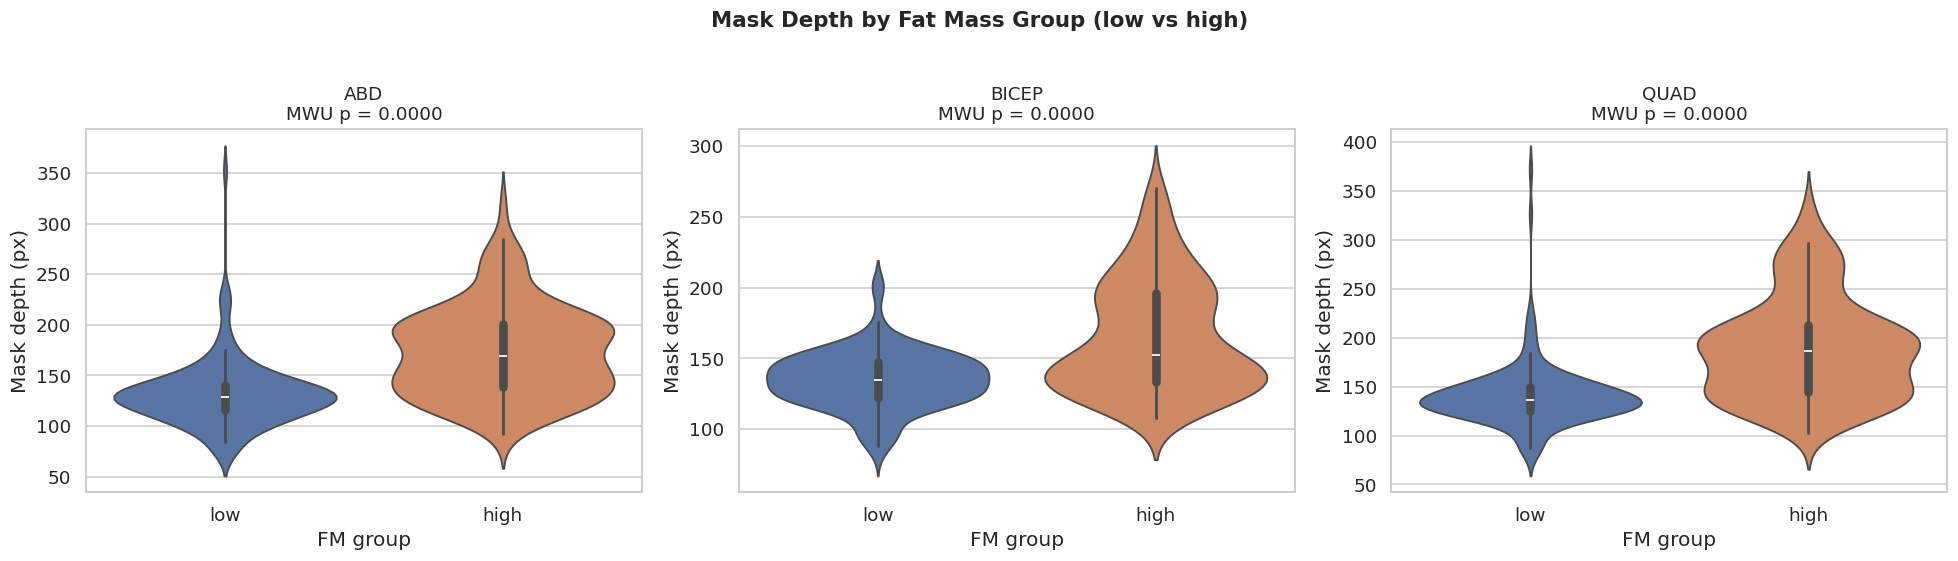

In [ ]:
regions = sorted(feat_df['region'].unique())
n_reg   = len(regions)

fig, axes = plt.subplots(1, n_reg, figsize=(6 * n_reg, 5), sharey=False)
if n_reg == 1:
    axes = [axes]

for ax, region in zip(axes, regions):
    sub = feat_df[feat_df['region'] == region]
    low_depths  = sub.loc[sub['fm_group'] == 'low',  'mask_depth'].dropna()
    high_depths = sub.loc[sub['fm_group'] == 'high', 'mask_depth'].dropna()

    stat, p = mannwhitneyu(low_depths, high_depths, alternative='two-sided')

    sns.violinplot(
        data=sub, x='fm_group', y='mask_depth',
        order=['low', 'high'], palette=['#4C72B0', '#DD8452'],
        inner='box', ax=ax
    )
    ax.set_title(f'{region.upper()}\nMWU p = {p:.4f}', fontsize=12)
    ax.set_xlabel('FM group'); ax.set_ylabel('Mask depth (px)')

plt.suptitle('Mask Depth by Fat Mass Group (low vs high)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mask_depth_fm_group.png', bbox_inches='tight')
plt.show()

### 5b. Mask Depth: Low vs High FFM

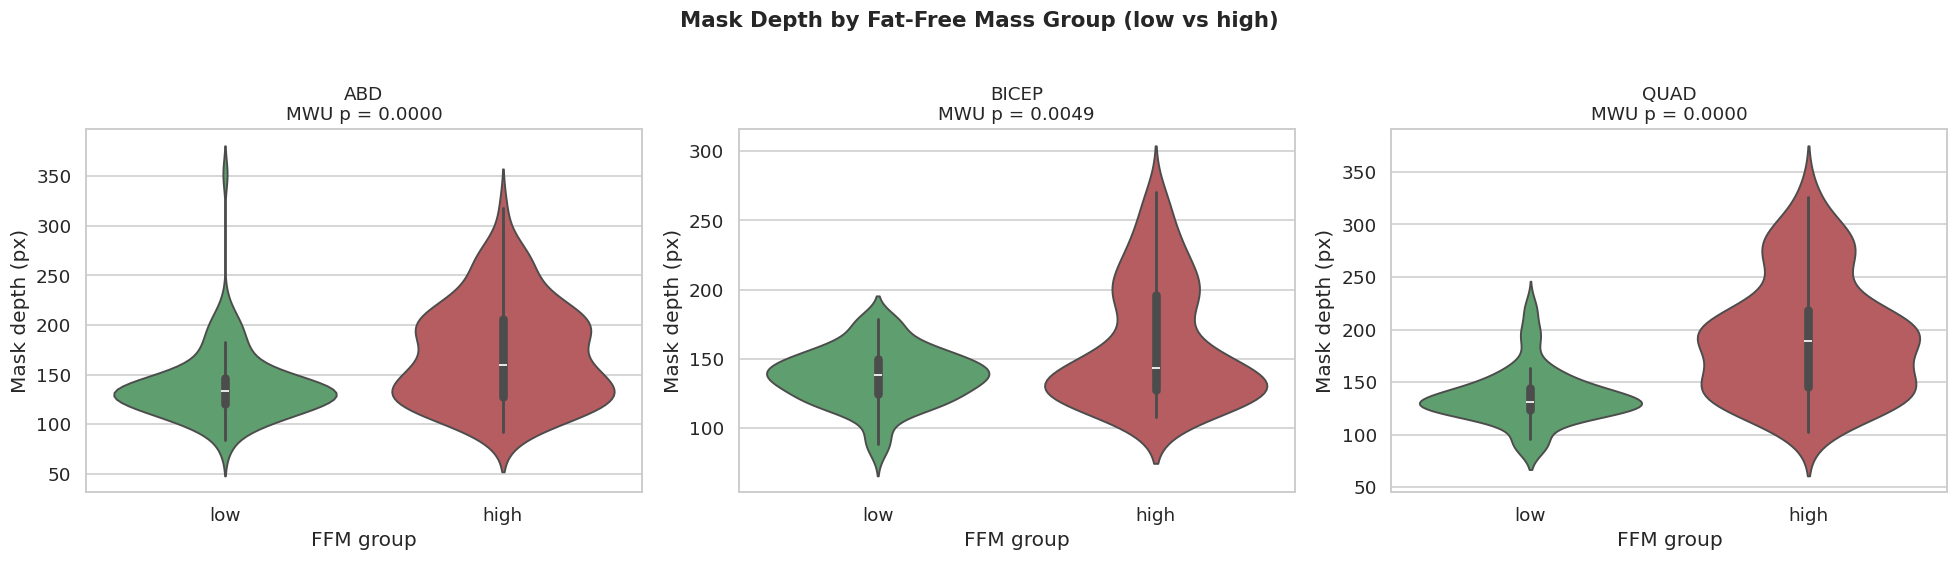

In [ ]:
df_lh_ffm = feat_df[feat_df['ffm_group'].isin(['low', 'high'])]

fig, axes = plt.subplots(1, n_reg, figsize=(6 * n_reg, 5), sharey=False)
if n_reg == 1:
    axes = [axes]

for ax, region in zip(axes, regions):
    sub = df_lh_ffm[df_lh_ffm['region'] == region]
    low_d  = sub.loc[sub['ffm_group'] == 'low',  'mask_depth'].dropna()
    high_d = sub.loc[sub['ffm_group'] == 'high', 'mask_depth'].dropna()

    stat, p = mannwhitneyu(low_d, high_d, alternative='two-sided')

    sns.violinplot(
        data=sub, x='ffm_group', y='mask_depth',
        order=['low', 'high'], palette=['#55A868', '#C44E52'],
        inner='box', ax=ax
    )
    ax.set_title(f'{region.upper()}\nMWU p = {p:.4f}', fontsize=12)
    ax.set_xlabel('FFM group'); ax.set_ylabel('Mask depth (px)')

plt.suptitle('Mask Depth by Fat-Free Mass Group (low vs high)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mask_depth_ffm_group.png', bbox_inches='tight')
plt.show()

### 5c. FFT Features: Low vs High FM/FFM

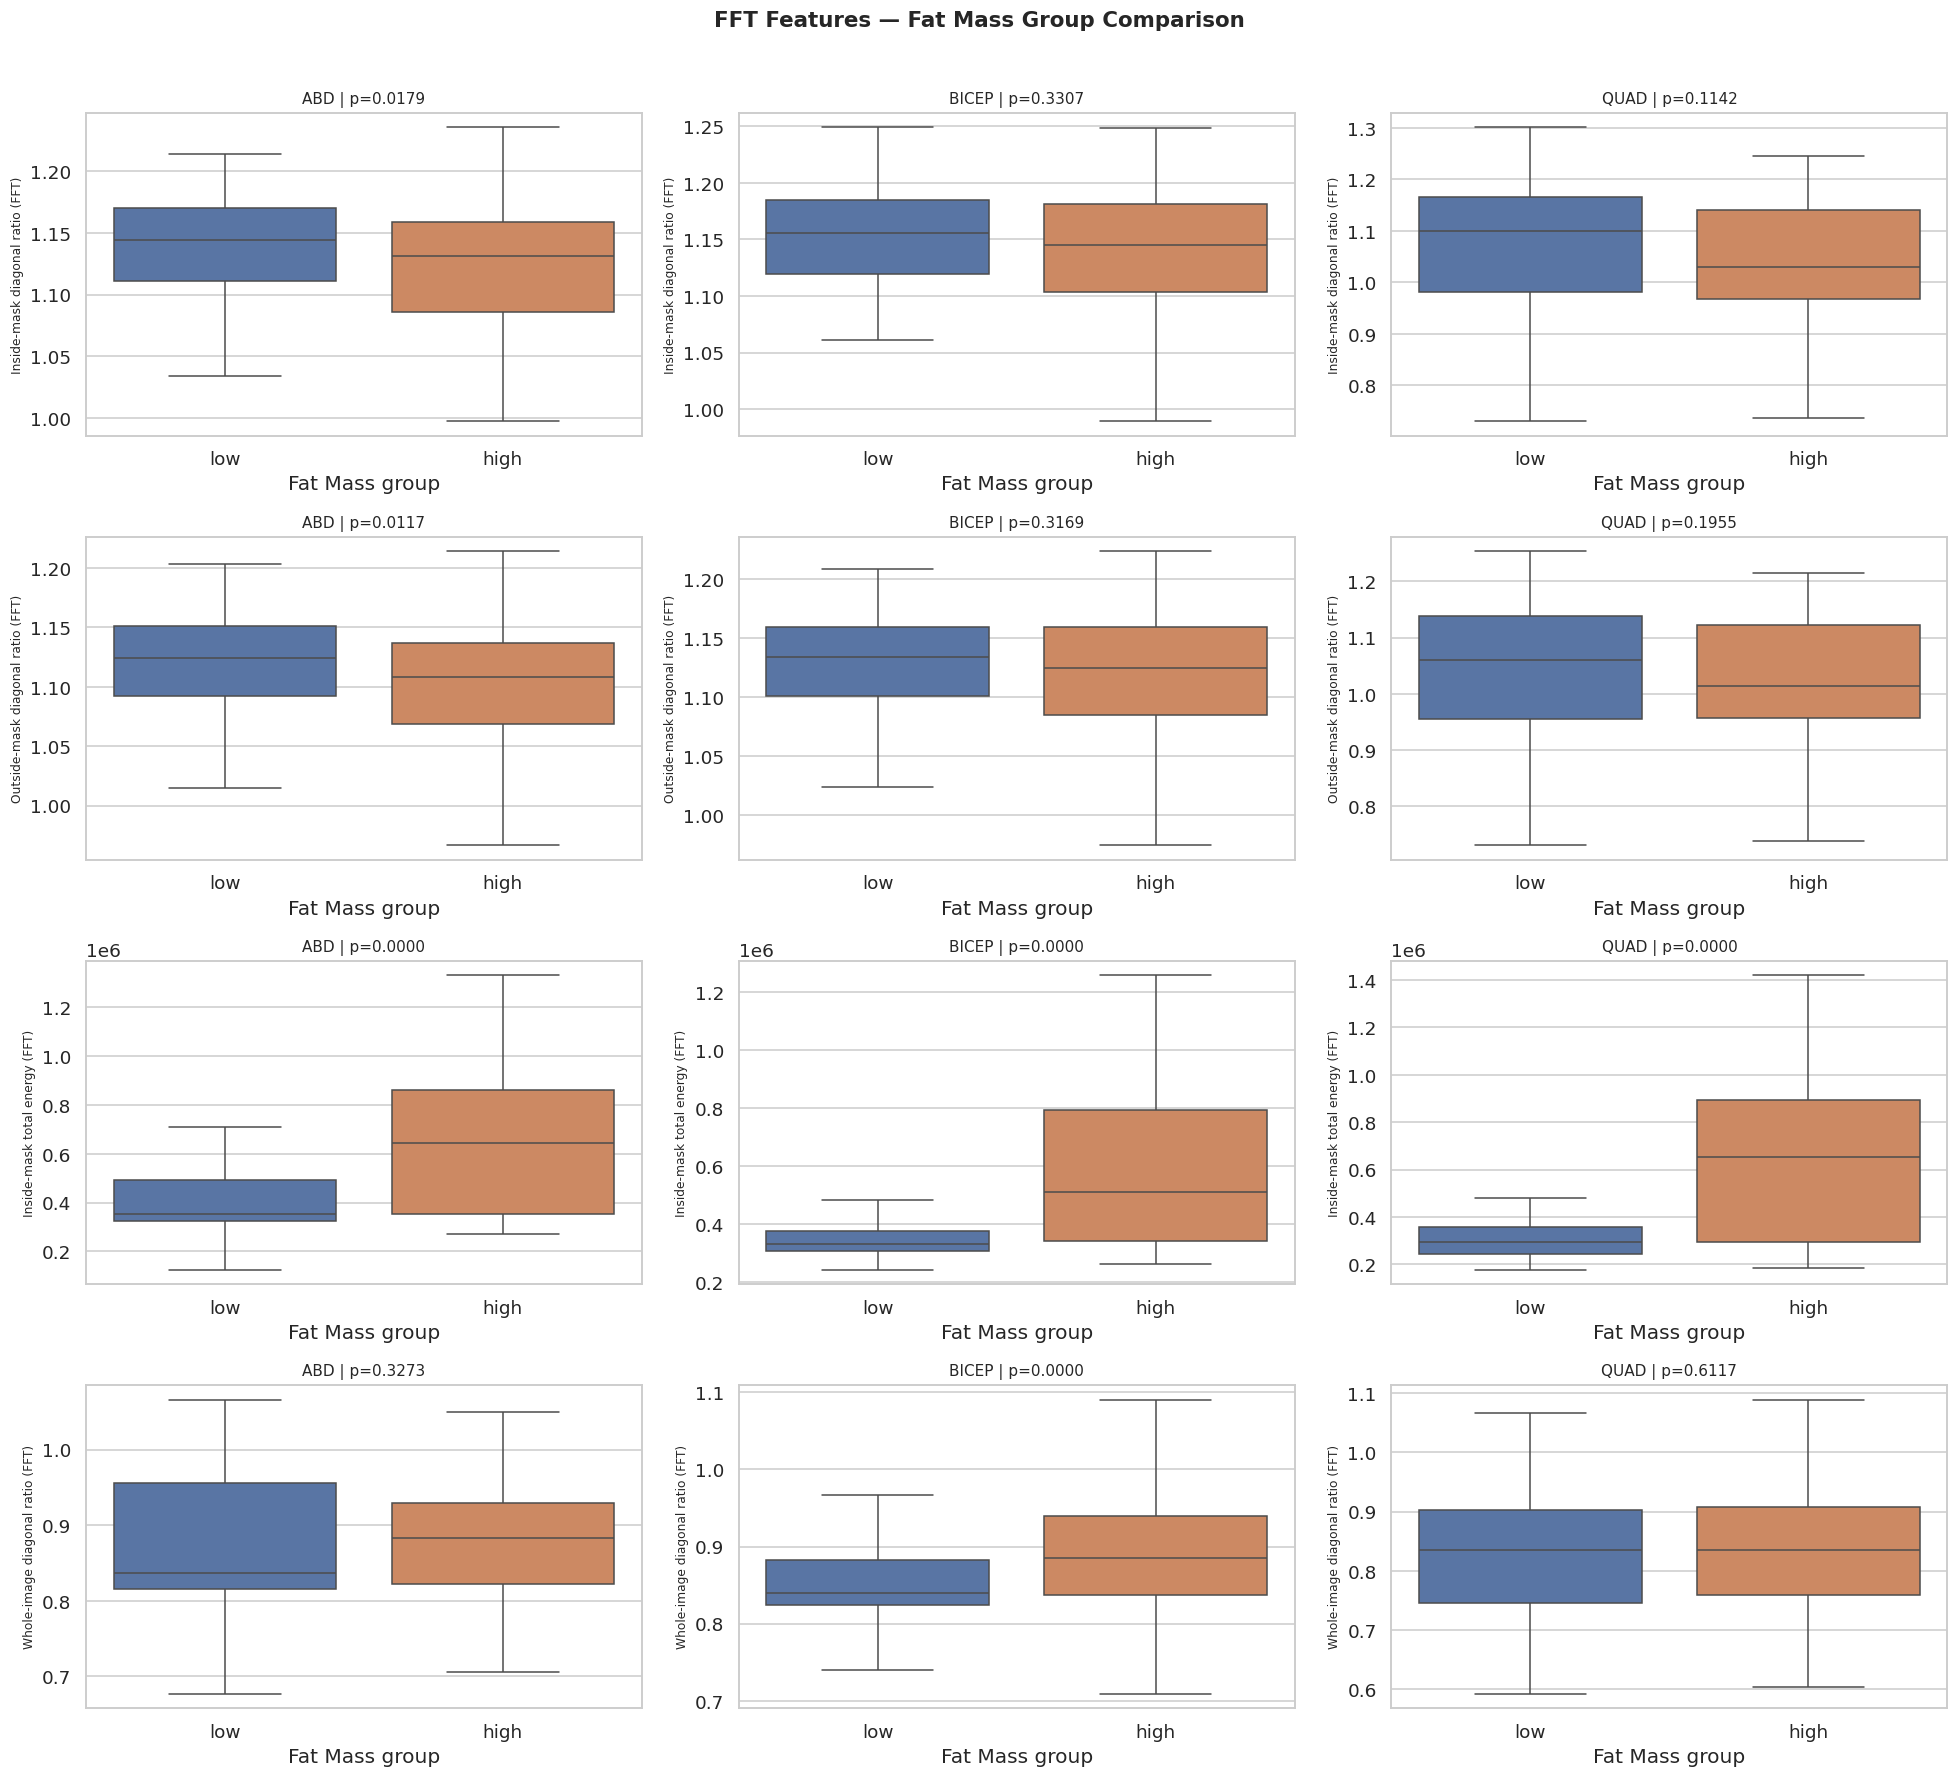

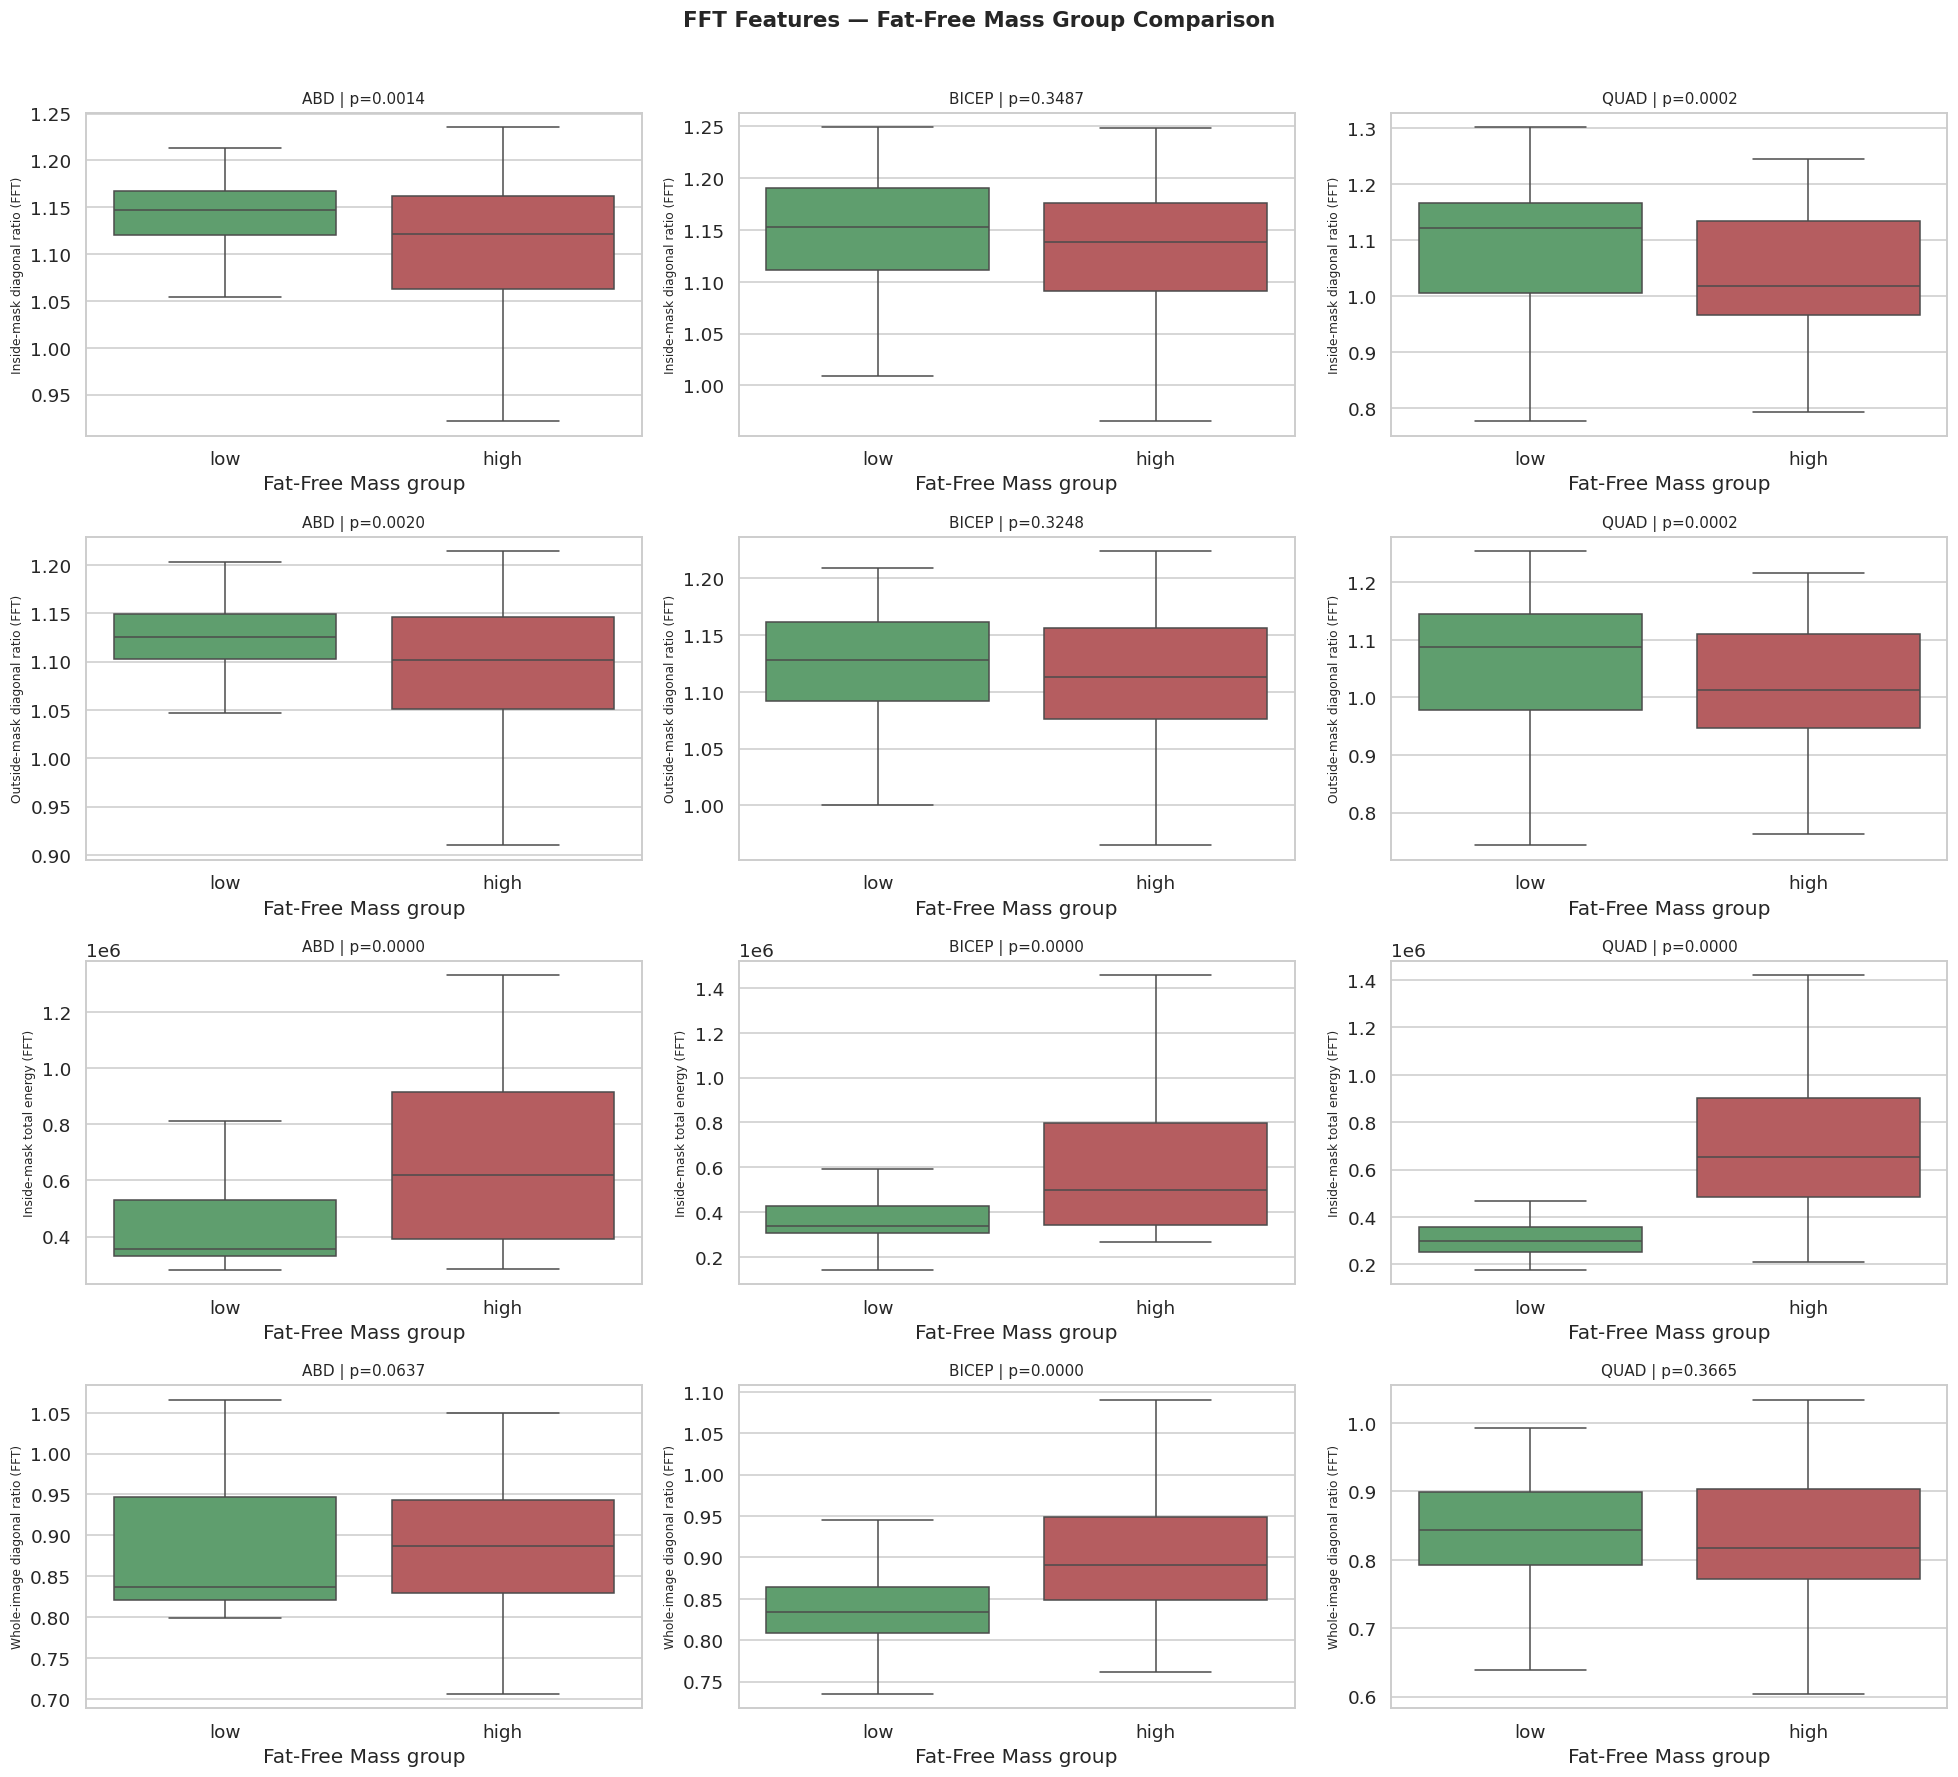

In [ ]:
FFT_FEATURES = [
    ('inside_diag_ratio',  'Inside-mask diagonal ratio (FFT)'),
    ('outside_diag_ratio', 'Outside-mask diagonal ratio (FFT)'),
    ('inside_energy',      'Inside-mask total energy (FFT)'),
    ('whole_diag_ratio',   'Whole-image diagonal ratio (FFT)'),
]

for group_col, group_label, pal in [
    ('fm_group',  'Fat Mass',      ['#4C72B0', '#DD8452']),
    ('ffm_group', 'Fat-Free Mass', ['#55A868', '#C44E52']),
]:
    sub_df = feat_df[feat_df[group_col].isin(['low', 'high'])]

    fig, axes = plt.subplots(
        len(FFT_FEATURES), n_reg,
        figsize=(6 * n_reg, 4 * len(FFT_FEATURES))
    )
    if n_reg == 1:
        axes = [[ax] for ax in axes]

    for f_idx, (feat_name, feat_label) in enumerate(FFT_FEATURES):
        for r_idx, region in enumerate(regions):
            ax  = axes[f_idx][r_idx]
            sub = sub_df[sub_df['region'] == region]

            low_v  = sub.loc[sub[group_col] == 'low',  feat_name].dropna()
            high_v = sub.loc[sub[group_col] == 'high', feat_name].dropna()

            if len(low_v) < 3 or len(high_v) < 3:
                ax.set_visible(False)
                continue

            stat, p = mannwhitneyu(low_v, high_v, alternative='two-sided')

            sns.boxplot(
                data=sub, x=group_col, y=feat_name,
                order=['low', 'high'], palette=pal,
                showfliers=False, ax=ax
            )
            ax.set_title(f'{region.upper()} | p={p:.4f}', fontsize=10)
            ax.set_xlabel(f'{group_label} group')
            ax.set_ylabel(feat_label, fontsize=8)

    plt.suptitle(f'FFT Features — {group_label} Group Comparison',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    fname = f'fft_features_{group_col}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

### 5d. Wavelet Features: Low vs High FM/FFM

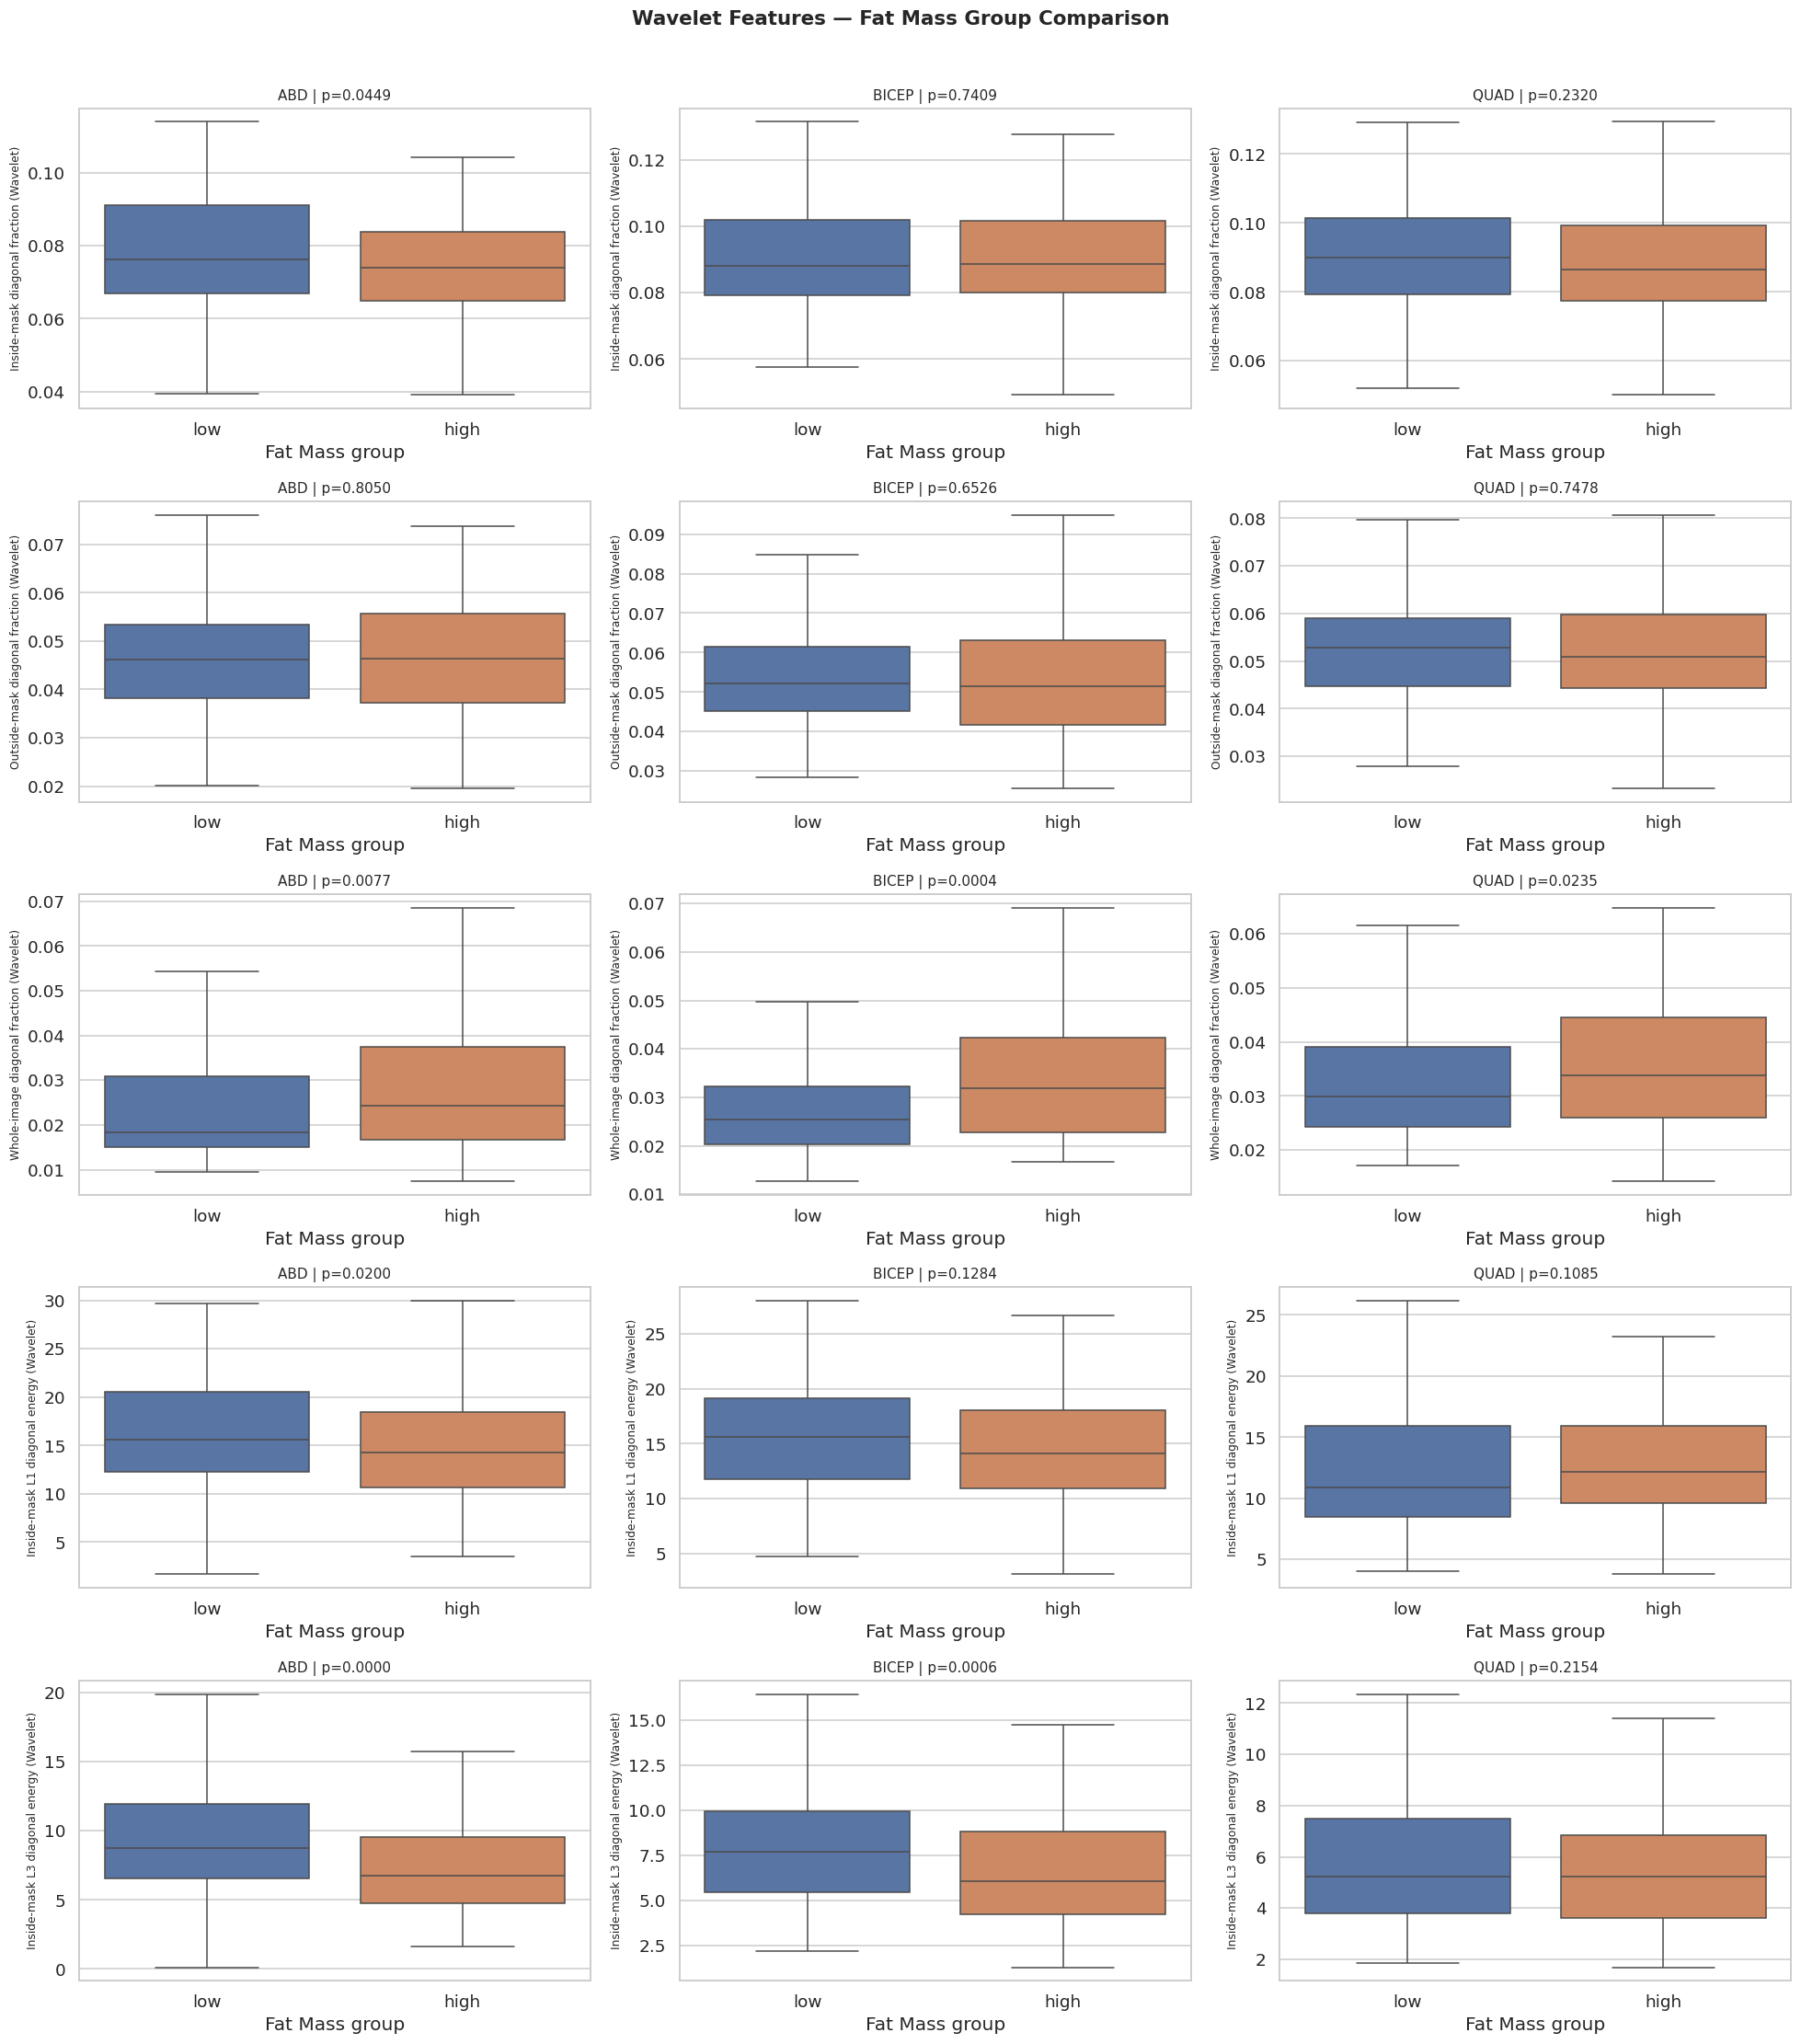

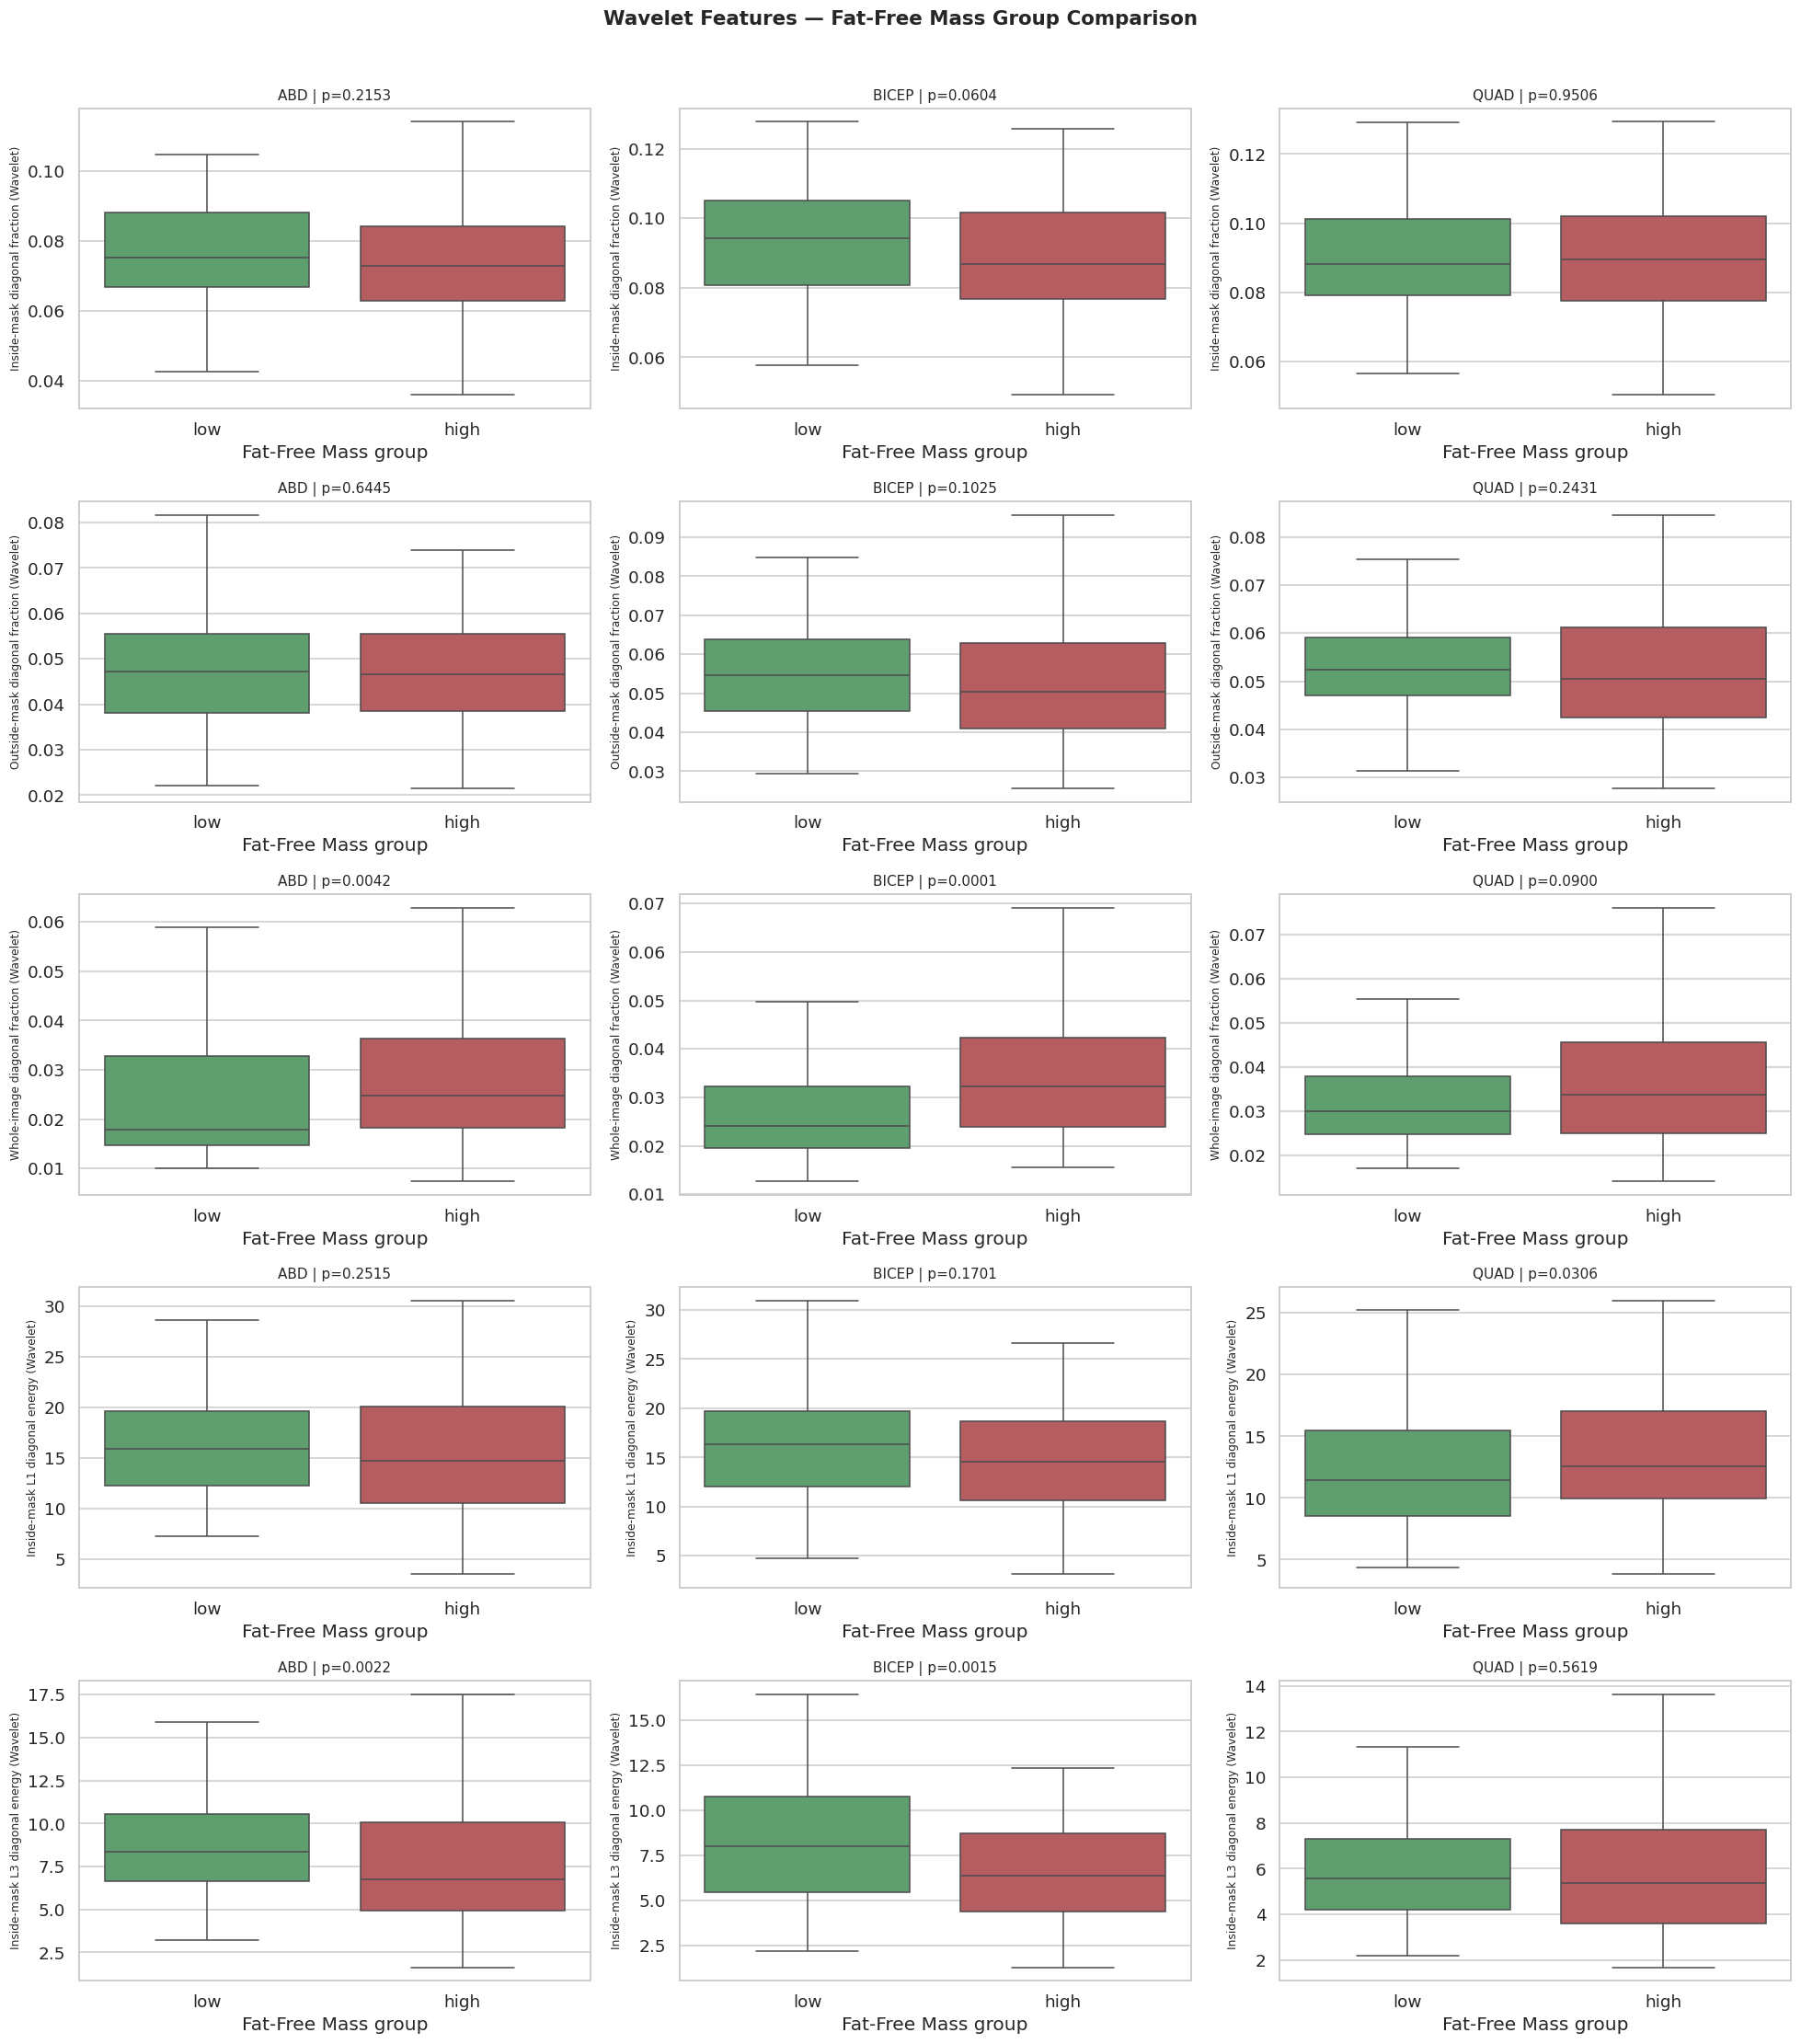

In [ ]:
WV_FEATURES = [
    ('inside_diag_fraction',  'Inside-mask diagonal fraction (Wavelet)'),
    ('outside_diag_fraction', 'Outside-mask diagonal fraction (Wavelet)'),
    ('whole_diag_fraction',   'Whole-image diagonal fraction (Wavelet)'),
    ('inside_L1_D_energy',    'Inside-mask L1 diagonal energy (Wavelet)'),
    ('inside_L3_D_energy',    'Inside-mask L3 diagonal energy (Wavelet)'),
]

# Filter to only features present in feat_df
WV_FEATURES = [(f, l) for f, l in WV_FEATURES if f in feat_df.columns]

for group_col, group_label, pal in [
    ('fm_group',  'Fat Mass',      ['#4C72B0', '#DD8452']),
    ('ffm_group', 'Fat-Free Mass', ['#55A868', '#C44E52']),
]:
    sub_df = feat_df[feat_df[group_col].isin(['low', 'high'])]

    fig, axes = plt.subplots(
        len(WV_FEATURES), n_reg,
        figsize=(6 * n_reg, 4 * len(WV_FEATURES))
    )
    if n_reg == 1:
        axes = [[ax] for ax in axes]

    for f_idx, (feat_name, feat_label) in enumerate(WV_FEATURES):
        for r_idx, region in enumerate(regions):
            ax  = axes[f_idx][r_idx]
            sub = sub_df[sub_df['region'] == region]

            low_v  = sub.loc[sub[group_col] == 'low',  feat_name].dropna()
            high_v = sub.loc[sub[group_col] == 'high', feat_name].dropna()

            if len(low_v) < 3 or len(high_v) < 3:
                ax.set_visible(False)
                continue

            stat, p = mannwhitneyu(low_v, high_v, alternative='two-sided')

            sns.boxplot(
                data=sub, x=group_col, y=feat_name,
                order=['low', 'high'], palette=pal,
                showfliers=False, ax=ax
            )
            ax.set_title(f'{region.upper()} | p={p:.4f}', fontsize=10)
            ax.set_xlabel(f'{group_label} group')
            ax.set_ylabel(feat_label, fontsize=8)

    plt.suptitle(f'Wavelet Features — {group_label} Group Comparison',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    fname = f'wavelet_features_{group_col}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

### 5e. Correlation Heatmap: Features vs FM / FFM

*still needs some debugging visually

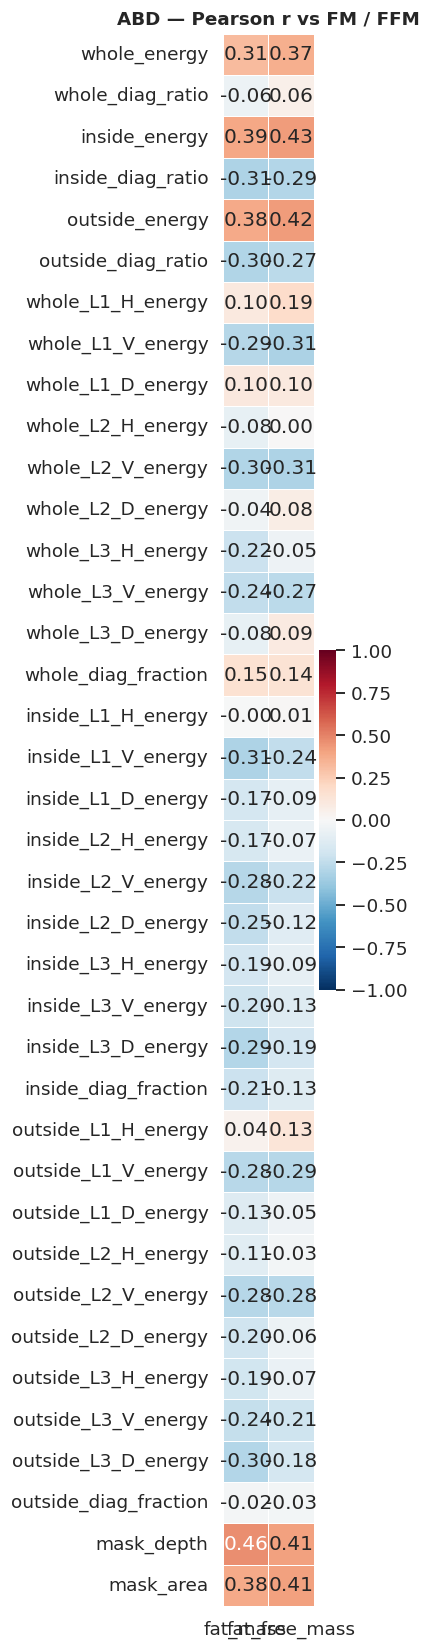

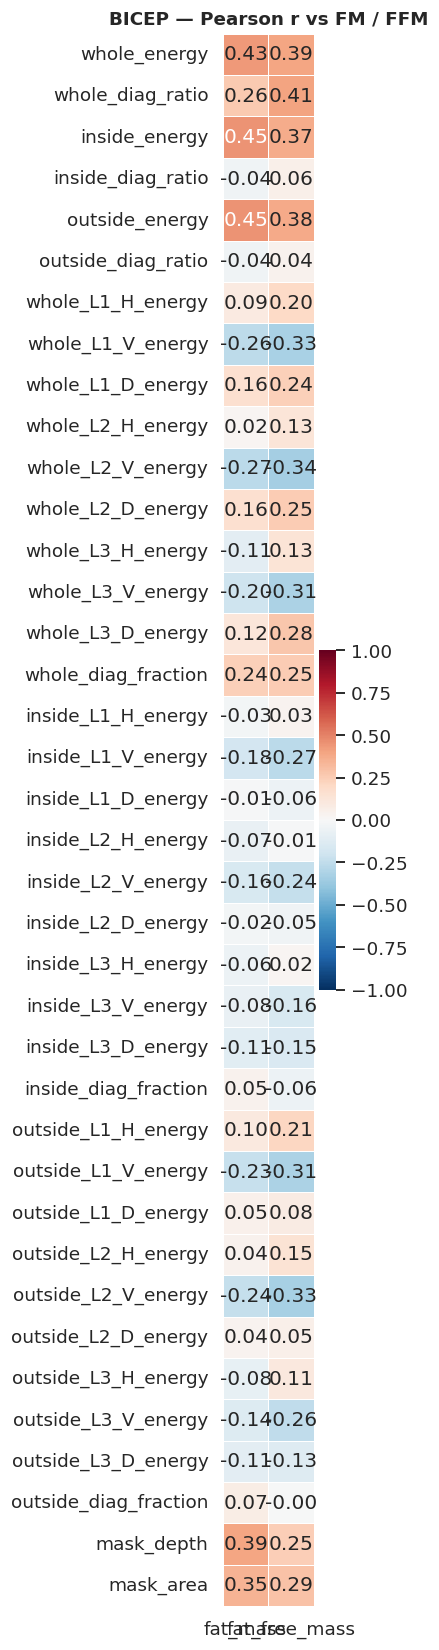

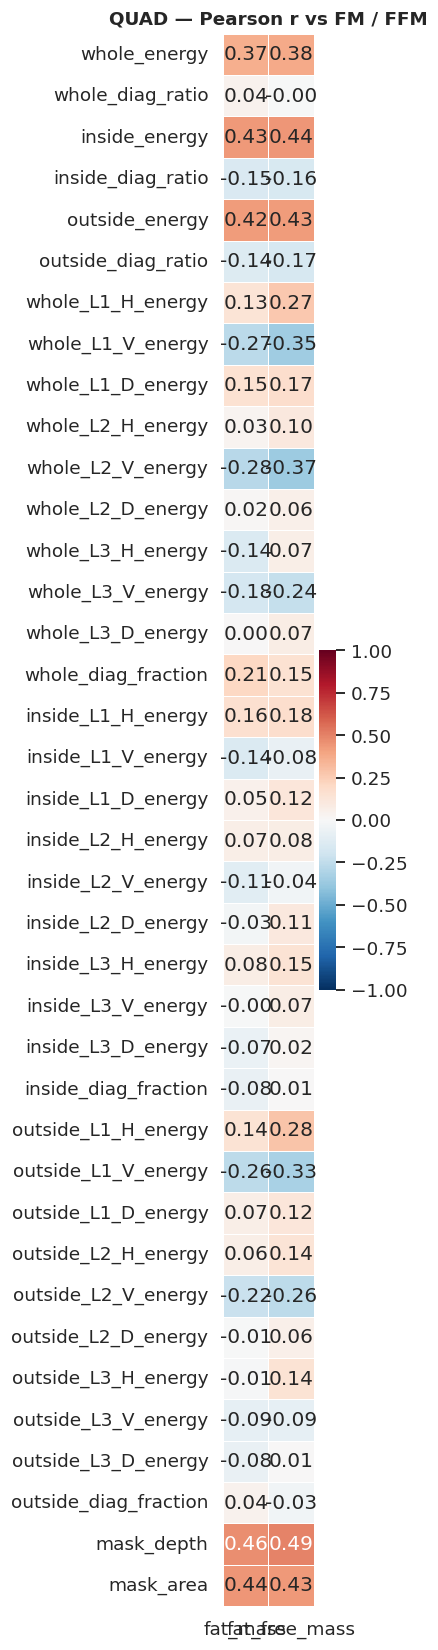

In [ ]:
# ── Pearson correlation of features against continuous FM / FFM ───────────────
spectral_cols = (
    [c for c in feat_df.columns if 'diag' in c or 'energy' in c]
    + ['mask_depth', 'mask_area']
)
spectral_cols = [c for c in spectral_cols if c in feat_df.columns]

targets = ['fat_mass', 'fat_free_mass']

for region in regions:
    sub = feat_df[feat_df['region'] == region].dropna(subset=spectral_cols + targets)
    if len(sub) < 10:
        continue

    corr_mat = pd.DataFrame(
        index=spectral_cols,
        columns=targets,
        dtype=float
    )
    for feat in spectral_cols:
        for tgt in targets:
            vals = sub[[feat, tgt]].dropna()
            if len(vals) < 5:
                corr_mat.loc[feat, tgt] = np.nan
            else:
                r, _ = pearsonr(vals[feat], vals[tgt])
                corr_mat.loc[feat, tgt] = r

    fig, ax = plt.subplots(figsize=(4, max(6, len(spectral_cols) * 0.4)))
    sns.heatmap(
        corr_mat.astype(float),
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        annot=True, fmt='.2f', linewidths=0.5,
        ax=ax
    )
    ax.set_title(f'{region.upper()} — Pearson r vs FM / FFM', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'corr_heatmap_{region}.png', bbox_inches='tight')
    plt.show()

### 5f. Summary Statistics Table

In [ ]:
# summary statisics table to be exported
summary_cols = ['mask_depth', 'mask_area',
                'inside_diag_ratio', 'outside_diag_ratio',
                'inside_diag_fraction', 'whole_diag_fraction']
summary_cols = [c for c in summary_cols if c in feat_df.columns]

summary = (
    feat_df[feat_df['fm_group'].isin(['low', 'high'])]
    .groupby(['region', 'fm_group'], observed=True)[summary_cols]
    .agg(['mean', 'std'])
    .round(4)
)

print('=== Feature Summary: Low vs High FM by Region ===')
display(summary)

# save to CSV
feat_df.to_csv('mask_analysis_features.csv', index=False)
print('\nFull feature table saved → mask_analysis_features.csv')

=== Feature Summary: Low vs High FM by Region ===


mask_depth            mask_area             inside_diag_ratio  \
                      mean      std        mean         std              mean   
region fm_group                                                                 
abd    high       173.6014  44.6513  80774.1069  41179.4860            1.1090   
       low        131.6450  33.1896  56324.2766  30979.3541            1.1317   
bicep  high       165.3647  39.7599  82405.9928  41264.4826            1.1353   
       low        134.8384  20.3934  54381.5461  28205.7759            1.1346   
quad   high       188.6698  51.7849  91380.8466  48824.7126            1.0431   
       low        140.4775  33.1326  49453.2038  30588.4865            1.0604   

                        outside_diag_ratio         inside_diag_fraction  \
                    std               mean     std                 mean   
region fm_group                                                           
abd    high      0.0852             1.0890  0.0840               0.0739   
       low       0.0630             1.1112  0.0640               0.0780   
bicep  high      0.0671             1.1121  0.0658               0.0907   
       low       0.0857             1.1121  0.0827               0.0901   
quad   high      0.1087             1.0217  0.1063               0.0880   
       low       0.1266             1.0347  0.1212               0.0901   

                        whole_diag_fraction          
                    std                mean     std  
region fm_group                                      
abd    high      0.0138              0.0283  0.0141  
       low       0.0152              0.0251  0.0149  
bicep  high      0.0154              0.0348  0.0150  
       low       0.0162              0.0291  0.0130  
quad   high      0.0167              0.0357  0.0122  
       low       0.0159              0.0328  0.0113


Full feature table saved → mask_analysis_features.csv
